# Web scrapping des donées d'importations de climatiseurs à destination de la Cote d'ivoire à partir du site de l'ITC

In [2]:
# Install a pip comtradeapicall package in the current Jupyter kernel
import sys
!{sys.executable} -m pip install --upgrade comtradeapicall

In [3]:
import requests

url = "https://comtradeapi.un.org/data/v1/get/C/A/HS"

params = {
    "reporterCode": "384",
    "cmdCode": "841510",
    "flowCode": "M",
    "period": "2015"
}

r = requests.get(url, params=params)

print(r.json())

{'statusCode': 401, 'message': 'Access denied due to missing subscription key. Make sure to include subscription key when making requests to an API.'}


In [4]:
# Install a pip pandas package in the current Jupyter kernel
import sys
!{sys.executable} -m pip install pandas

In [5]:
import pandas
import requests
import comtradeapicall

In [6]:
import importlib.metadata
version = importlib.metadata.version("comtradeapicall")
print("comtradeapicall version:", version)

comtradeapicall version: 1.3.0


In [7]:
# comtrade api subscription key (from comtradedeveloper.un.org)
subscription_key = '526c2b3fb7ee4f50b13316cf480862ef'
directory = "C:\CIRED\Raw data"  # output directory for downloaded files
#proxy_url = '<PROXY URL>'  # optional if you need proxy url

<>:3: SyntaxWarning: invalid escape sequence '\C'
<>:3: SyntaxWarning: invalid escape sequence '\C'
C:\Users\emman\AppData\Local\Temp\ipykernel_22668\4029549968.py:3: SyntaxWarning: invalid escape sequence '\C'
  directory = "C:\CIRED\Raw data"  # output directory for downloaded files


In [8]:
# set some variables
from datetime import date
from datetime import timedelta
today = date.today()
yesterday = today - timedelta(days=1)
lastweek = today - timedelta(days=7)

In [14]:
import pandas as pd

all_data = []

# -----------------------------
# 1. DONNÉES MENSUELLES 2015-2019
# -----------------------------
for year in range(2015, 2020):

    period = ",".join([f"{year}{m:02d}" for m in range(1,13)])

    df = comtradeapicall.previewFinalData(
        typeCode='C',
        freqCode='M',
        clCode='HS',
        period=period,
        reporterCode='384',      # Côte d'Ivoire
        cmdCode='841510,841581,841582',
        flowCode='M',
        partnerCode=None,        # tous les partenaires
        partner2Code=None,
        customsCode=None,
        motCode=None,
        maxRecords=50000,
        format_output='JSON',
        aggregateBy=None,
        breakdownMode='classic',
        countOnly=None,
        includeDesc=True
    )

    if df is not None:
        all_data.append(df)

# -----------------------------
# 2. DONNÉES ANNUELLES 2020-2024
# -----------------------------
for year in range(2020, 2025):

    df = comtradeapicall.previewFinalData(
        typeCode='C',
        freqCode='A',            # annuel
        clCode='HS',
        period=str(year),
        reporterCode='384',
        cmdCode='841510,841581,841582',
        flowCode='M',
        partnerCode=None,        # tous les partenaires
        partner2Code=None,
        customsCode=None,
        motCode=None,
        maxRecords=50000,
        format_output='JSON',
        aggregateBy=None,
        breakdownMode='classic',
        countOnly=None,
        includeDesc=True
    )

    if df is not None:
        all_data.append(df)

# -----------------------------
# 3. CONCATÉNER
# -----------------------------
final_df = pd.concat(all_data, ignore_index=True)

print(final_df.head())

  typeCode freqCode  refPeriodId  refYear  refMonth  period  reporterCode  \
0        C        M     20150101     2015         1  201501           384   
1        C        M     20150101     2015         1  201501           384   
2        C        M     20150101     2015         1  201501           384   
3        C        M     20150101     2015         1  201501           384   
4        C        M     20150101     2015         1  201501           384   

  reporterISO   reporterDesc flowCode  ...    netWgt  isNetWgtEstimated  \
0         CIV  Côte d'Ivoire        M  ...  121436.0              False   
1         CIV  Côte d'Ivoire        M  ...   95854.0              False   
2         CIV  Côte d'Ivoire        M  ...     614.0              False   
3         CIV  Côte d'Ivoire        M  ...     185.0              False   
4         CIV  Côte d'Ivoire        M  ...    4425.0              False   

  grossWgt isGrossWgtEstimated    cifvalue fobvalue primaryValue  \
0        0        

In [15]:
final_df.to_excel("CIV_AC_imports_2015_2025.xlsx", index=False)

In [16]:
print(final_df.columns)

Index(['typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'period',
       'reporterCode', 'reporterISO', 'reporterDesc', 'flowCode', 'flowDesc',
       'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code',
       'partner2ISO', 'partner2Desc', 'classificationCode',
       'classificationSearchCode', 'isOriginalClassification', 'cmdCode',
       'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc',
       'mosCode', 'motCode', 'motDesc', 'qtyUnitCode', 'qtyUnitAbbr', 'qty',
       'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty',
       'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt',
       'isGrossWgtEstimated', 'cifvalue', 'fobvalue', 'primaryValue',
       'legacyEstimationFlag', 'isReported', 'isAggregate'],
      dtype='object')


## Extraire la nouvelle base pour le produit 841510

In [17]:
# Filtrer le produit
df_841510 = final_df[final_df["cmdCode"] == "841510"].copy()

# Sélection des variables nécessaires
df_841510 = df_841510[
    [
        "reporterISO",
        "partnerISO",
        "refYear",
        "refMonth",
        "primaryValue",
        "qty",
        "netWgt"
    ]
]

# Renommer pour plus de clarté
df_841510 = df_841510.rename(columns={
    "primaryValue": "value_usd",
    "netWgt": "weight_kg"
})

print(df_841510.head())

  reporterISO partnerISO  refYear  refMonth   value_usd       qty  weight_kg
0         CIV        W00     2015         1  739012.249  2010.394   121436.0
1         CIV        CHN     2015         1  307827.405   837.407    95854.0
2         CIV        FRA     2015         1    5830.981    15.862      614.0
3         CIV        DEU     2015         1     152.063     0.414      185.0
4         CIV        ITA     2015         1  134408.293   365.642     4425.0


## Nettoyer les variables numériques

In [18]:
df_841510["value_usd"] = pd.to_numeric(df_841510["value_usd"], errors="coerce")
df_841510["qty"] = pd.to_numeric(df_841510["qty"], errors="coerce")
df_841510["weight_kg"] = pd.to_numeric(df_841510["weight_kg"], errors="coerce")

## Calculer le prix relatif ($/kg)

In [19]:
df_841510["price_usd_per_kg"] = df_841510["value_usd"] / df_841510["weight_kg"]

## le prix moyen par pays exportateur
price_by_country = (
    df_841510.groupby("partnerISO")["price_usd_per_kg"]
    .mean()
    .sort_values(ascending=False)
)
print(price_by_country.head(10))

partnerISO
LTU    397.897500
NGA    128.368171
JPN     90.910952
_X      85.829425
HUN     85.230273
MEX     83.633530
MLI     73.876185
AUT     60.254459
GHA     50.383070
PRT     40.105031
Name: price_usd_per_kg, dtype: float64


## Calcul de la part de marché des pays

In [20]:
# total monde
world_imports = df_841510[df_841510["partnerISO"] == "W00"]

total_world_value = world_imports["value_usd"].sum()

# importations par pays
country_imports = df_841510[df_841510["partnerISO"] != "W00"]

market_share = (
    country_imports.groupby("partnerISO")["value_usd"]
    .sum() / total_world_value
)

market_share = market_share.sort_values(ascending=False)

print(market_share.head(10))

partnerISO
CHN    0.795342
ESP    0.033100
FRA    0.027798
IND    0.023974
MYS    0.019595
ITA    0.018675
THA    0.015415
KOR    0.011434
ARE    0.009889
BEL    0.007129
Name: value_usd, dtype: float64


## Identifier les 5 principaux exportateurs

In [21]:
top5 = (
    country_imports.groupby("partnerISO")["value_usd"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

print(top5)

Index(['CHN', 'ESP', 'FRA', 'IND', 'MYS'], dtype='object', name='partnerISO')


## Agréger les données par année

In [27]:
top5_data = country_imports[country_imports["partnerISO"].isin(top5)]

annual_data = (
    top5_data.groupby(["refYear", "partnerISO"])
    .agg({
        "value_usd": "sum",
        "qty": "sum",
        "weight_kg": "sum"
    })
    .reset_index()
)

## Calcul de la part annuelle dans le total

In [28]:
world_year = (
    world_imports.groupby("refYear")["value_usd"]
    .sum()
    .reset_index()
    .rename(columns={"value_usd": "world_value"})
)

annual_data = annual_data.merge(world_year, on="refYear")

annual_data["market_share"] = annual_data["value_usd"] / annual_data["world_value"]

## Plot de l'évolution des valeurs en dollars

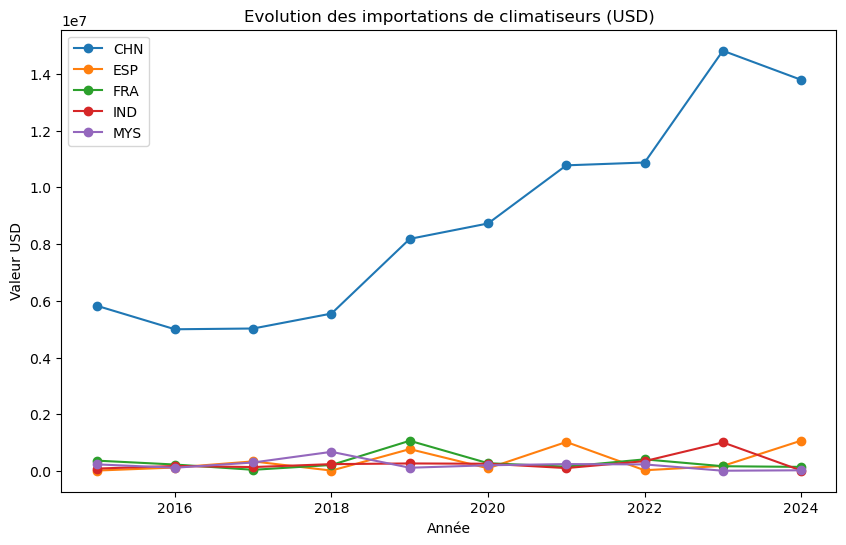

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for country in top5:
    temp = annual_data[annual_data["partnerISO"] == country]
    plt.plot(temp["refYear"], temp["value_usd"], marker="o", label=country)

plt.title("Evolution des importations de climatiseurs (USD)")
plt.xlabel("Année")
plt.ylabel("Valeur USD")
plt.legend()
plt.show()

## Plot de l'évolution des quantités

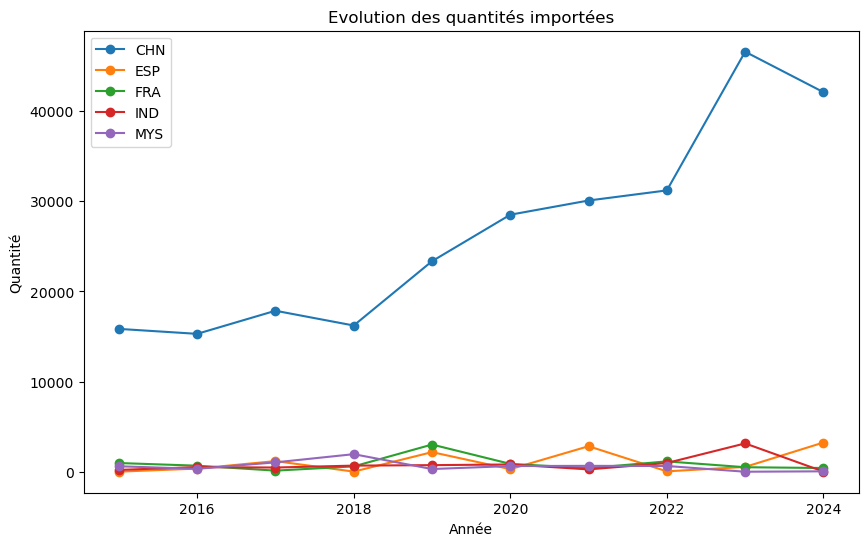

In [30]:
plt.figure(figsize=(10,6))

for country in top5:
    temp = annual_data[annual_data["partnerISO"] == country]
    plt.plot(temp["refYear"], temp["qty"], marker="o", label=country)

plt.title("Evolution des quantités importées")
plt.xlabel("Année")
plt.ylabel("Quantité")
plt.legend()
plt.show()

## Plot de l'évolution de la part de marché

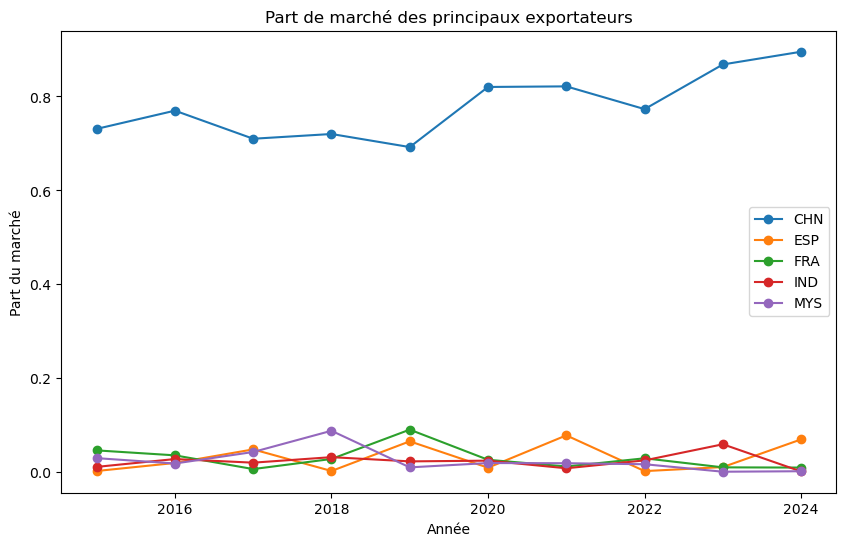

In [31]:
plt.figure(figsize=(10,6))

for country in top5:
    temp = annual_data[annual_data["partnerISO"] == country]
    plt.plot(temp["refYear"], temp["market_share"], marker="o", label=country)

plt.title("Part de marché des principaux exportateurs")
plt.xlabel("Année")
plt.ylabel("Part du marché")
plt.legend()
plt.show()

## Scrapping des données de ITC

In [1]:
!pip install selenium
!pip install webdriver_manager
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import time


In [2]:
# Configuration téléchargement automatique
options = webdriver.ChromeOptions()
options.add_experimental_option("prefs", {
    "download.default_directory": r"C:\Users\emman\Downloads\ITC_data",
    "download.prompt_for_download": False,
    "download.directory_upgrade": True
})

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)


In [45]:
try:
    driver.quit()
except:
    pass

In [4]:
# Ouvrir trade map
driver.get("https://www.trademap.org")

print("Connecte-toi manuellement dans les 40 secondes...")
time.sleep(40)                 ### ou wait = WebDriverWait(driver, 30)

# Aller directement sur page climatiseur mensuel
url = "https://www.trademap.org/Country_SelCountry_MQ_TS.aspx?nvpm=1|384||||841510||||6|1|1|1|2|3|2|1|1|1"
driver.get(url)

time.sleep(10)

'''
# Cliquer sur Download Excel
download_button = driver.find_element(By.ID, "ctl00_PageContent_ButtonDownload")
download_button.click()

time.sleep(10)

driver.quit()
'''

Connecte-toi manuellement dans les 40 secondes...


NoSuchElementException: Message: no such element: Unable to locate element: {"method":"css selector","selector":"[id="ctl00_PageContent_ButtonDownload"]"}
  (Session info: chrome=146.0.7680.165); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#nosuchelementexception
Stacktrace:
	chromedriver!GetHandleVerifier [0x6dcdf3+10b03]
	chromedriver!GetHandleVerifier [0x6dcf24+10c34]
	chromedriver!(No symbol) [0x4c2120]
	chromedriver!(No symbol) [0x50abca]
	chromedriver!(No symbol) [0x50ae6b]
	chromedriver!(No symbol) [0x54d0b2]
	chromedriver!(No symbol) [0x52db54]
	chromedriver!(No symbol) [0x54a9a5]
	chromedriver!(No symbol) [0x52d8a6]
	chromedriver!(No symbol) [0x500229]
	chromedriver!(No symbol) [0x500fe4]
	chromedriver!GetHandleVerifier [0x9448b9+2785c9]
	chromedriver!GetHandleVerifier [0x93feb5+273bc5]
	chromedriver!GetHandleVerifier [0x95e06b+291d7b]
	chromedriver!GetHandleVerifier [0x6f5cc8+299d8]
	chromedriver!GetHan

In [5]:
print(driver.current_url)
print(driver.title)

https://www.trademap.org/Country_SelCountry_MQ_TS.aspx?nvpm=1%7c384%7c%7c%7c%7c841510%7c%7c%7c6%7c1%7c1%7c1%7c2%7c3%7c2%7c1%7c1%7c1
Trade Map - List of supplying markets for a product imported by Côte d'Ivoire


In [6]:
print(driver.page_source[:2000])

<html id="ctl00_html" xmlns="http://www.w3.org/1999/xhtml"><head id="ctl00_header"><title>
	Trade Map - List of supplying markets for a product imported by Côte d'Ivoire
</title><meta http-equiv="Content-Type" content="text/html; charset=UTF-8"><meta name="rating" content="GENERAL"><meta name="distribution" content="GLOBAL"><meta name="classification" content="Business and Economy"><meta name="copyright" content="Copyright © 2008-2014 International Trade Centre. All rights reserved."><meta name="author" content="International Trade Centre (ITC)"><link rel="icon" href="img/ITC_logo_small.ico">
        
        

        

        <script type="text/javascript" async="" src="https://www.google-analytics.com/analytics.js"></script><script type="text/javascript" async="" src="https://www.googletagmanager.com/gtag/js?id=G-4GRY1NXMQS&amp;cx=c&amp;gtm=4e63p1"></script><script type="text/javascript">
            if (self === top) {
                var antiClickjack = document.getElementById("a

In [7]:
elements = driver.find_elements(By.XPATH, "//*[contains(translate(text(),'DOWNLOAD','download'),'download')]")
print("Nombre d'éléments trouvés :", len(elements))

for i, el in enumerate(elements):
    try:
        print(i, el.tag_name, el.text)
    except:
        pass

Nombre d'éléments trouvés : 1
0 span Download:


In [8]:
buttons = driver.find_elements(By.XPATH, "//a | //button | //input")
for i, b in enumerate(buttons[:100]):
    try:
        txt = b.text
        href = b.get_attribute("href")
        onclick = b.get_attribute("onclick")
        print(i, b.tag_name, txt, href, onclick)
    except:
        pass

0 input  None None
1 input  None None
2 input  None None
3 input  None None
4 input  None None
5 input  None None
6 a  http://www.intracen.org/ None
7 a  None None
8 input  None None
9 input  None None
10 a  None javascript:SendPrintPopup();
11 a  None NewWindowPopup();
12 a  None HidePopup();
13 a Home & Search https://www.trademap.org/Index.aspx None
14 a Data Availability https://www.trademap.org/Country_SelCountry_MQ_TS.aspx?nvpm=1%7c384%7c%7c%7c%7c841510%7c%7c%7c6%7c1%7c1%7c1%7c2%7c3%7c2%7c1%7c1%7c1# None
15 a  https://www.trademap.org/stDataAvailability.aspx None
16 a  https://www.trademap.org/stServiceDataAvailability.aspx None
17 a  https://www.trademap.org/stCompanies.aspx None
18 a Reference Material https://www.trademap.org/Country_SelCountry_MQ_TS.aspx?nvpm=1%7c384%7c%7c%7c%7c841510%7c%7c%7c6%7c1%7c1%7c1%7c2%7c3%7c2%7c1%7c1%7c1# None
19 a  https://www.trademap.org/Docs/TradeMap-Userguide-EN.pdf None
20 a  https://www.trademap.org/stFAQ.aspx None
21 a  https://www.trademap.o

In [9]:
download_candidates = [
    (By.XPATH, "//a[contains(., 'Download')]"),
    (By.XPATH, "//button[contains(., 'Download')]"),
    (By.XPATH, "//*[contains(text(), 'Download Excel')]"),
    (By.XPATH, "//img[contains(@title, 'Download')]"),
    (By.XPATH, "//a[contains(@title, 'Download')]"),
    (By.XPATH, "//input[contains(@value, 'Download')]")
]

for by, selector in download_candidates:
    elems = driver.find_elements(by, selector)
    print(selector, "->", len(elems))

//a[contains(., 'Download')] -> 0
//button[contains(., 'Download')] -> 0
//*[contains(text(), 'Download Excel')] -> 0
//img[contains(@title, 'Download')] -> 0
//a[contains(@title, 'Download')] -> 0
//input[contains(@value, 'Download')] -> 0


In [10]:
iframes = driver.find_elements(By.TAG_NAME, "iframe")
print("Nombre d'iframes :", len(iframes))

Nombre d'iframes : 1


In [11]:
for i, iframe in enumerate(iframes):
    driver.switch_to.default_content()
    driver.switch_to.frame(iframe)
    print("Dans iframe", i)
    elems = driver.find_elements(By.XPATH, "//*[contains(text(),'Download')]")
    print("Download trouvés :", len(elems))

Dans iframe 0
Download trouvés : 0


In [12]:
driver.switch_to.default_content()

In [13]:
print(driver.current_url)
print(driver.title)

elements = driver.find_elements(By.XPATH, "//*[contains(translate(text(),'DOWNLOAD','download'),'download')]")
print(len(elements))
for e in elements:
    print(e.tag_name, e.text)

https://www.trademap.org/Country_SelCountry_MQ_TS.aspx?nvpm=1%7c384%7c%7c%7c%7c841510%7c%7c%7c6%7c1%7c1%7c1%7c2%7c3%7c2%7c1%7c1%7c1
Trade Map - List of supplying markets for a product imported by Côte d'Ivoire
1
span Download:


In [14]:
iframes = driver.find_elements(By.TAG_NAME, "iframe")
print("iframes =", len(iframes))

iframes = 1


In [1]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

options = webdriver.ChromeOptions()
options.page_load_strategy = "eager"
options.add_argument("--start-maximized")

prefs = {
    "download.default_directory": r"C:\Users\emman\Downloads\ITC_data",
    "download.prompt_for_download": False,
    "download.directory_upgrade": True,
    "safebrowsing.enabled": True
}
options.add_experimental_option("prefs", prefs)

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

driver.set_page_load_timeout(30)

In [2]:

'''
import os
import time
from pathlib import Path
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

download_dir = Path(r"C:\Users\emman\Downloads\ITC_data")
download_dir.mkdir(parents=True, exist_ok=True)

before = set(p.name for p in download_dir.iterdir())

driver.get("https://www.trademap.org/Country_SelCountry_MQ_TS.aspx?nvpm=1%7c384%7c%7c%7c%7c841510%7c%7c%7c6%7c1%7c1%7c1%7c2%7c3%7c2%7c1%7c1%7c1")

wait = WebDriverWait(driver, 20)

# on cible le premier lien image juste après "Download:"
excel_link = wait.until(
    EC.presence_of_element_located((
        By.XPATH,
        "//*[contains(text(),'Download:')]/following::a[1]"
    ))
)

print(excel_link.get_attribute("outerHTML"))

# clic normal
excel_link.click()

# ensuite on attend l'apparition d'un nouveau fichier
timeout = 60
start = time.time()

downloaded_file = None
while time.time() - start < timeout:
    current = set(p.name for p in download_dir.iterdir())
    new_files = current - before

    # ignorer les téléchargements partiels
    complete_files = [
        f for f in new_files
        if not f.endswith(".crdownload") and not f.endswith(".tmp")
    ]

    if complete_files:
        downloaded_file = complete_files[0]
        break

    time.sleep(1)

print("Fichier téléchargé :", downloaded_file)
'''

<a onclick="javascript:SendPrint();"><img src="/img/imprim.gif" alt="Print" style="cursor:pointer;Width:20px;Height:20px"></a>


ReadTimeoutError: HTTPConnectionPool(host='localhost', port=52294): Read timed out. (read timeout=120)

In [2]:
'''
from pathlib import Path
import time
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

download_dir = Path(r"C:\Users\emman\Downloads\ITC_data")
download_dir.mkdir(parents=True, exist_ok=True)

before = set(p.name for p in download_dir.iterdir())

driver.get("https://www.trademap.org/Country_SelCountry_MQ_TS.aspx?nvpm=1%7c384%7c%7c%7c%7c841510%7c%7c%7c6%7c1%7c1%7c1%7c2%7c3%7c2%7c1%7c1%7c1")

wait = WebDriverWait(driver, 20)

# cible l'icône Excel, pas l'imprimante
excel_img = wait.until(
    EC.presence_of_element_located((
        By.XPATH,
        "//img[contains(@src,'xls') or contains(@src,'excel') or contains(@alt,'Excel') or contains(@title,'Excel')]"
    ))
)

print(excel_img.get_attribute("outerHTML"))

# cliquer le lien parent
excel_link = excel_img.find_element(By.XPATH, "./ancestor::a[1]")
print(excel_link.get_attribute("outerHTML"))

excel_link.click()

timeout = 60
start = time.time()
downloaded_file = None

while time.time() - start < timeout:
    current = set(p.name for p in download_dir.iterdir())
    new_files = current - before

    complete_files = [
        f for f in new_files
        if not f.endswith(".crdownload") and not f.endswith(".tmp")
    ]

    if complete_files:
        downloaded_file = complete_files[0]
        break

    time.sleep(1)

print("Fichier téléchargé :", downloaded_file)
'''

TimeoutException: Message: 
Stacktrace:
	chromedriver!GetHandleVerifier [0x6dcdf3+10b03]
	chromedriver!GetHandleVerifier [0x6dcf24+10c34]
	chromedriver!(No symbol) [0x4c2120]
	chromedriver!(No symbol) [0x50abca]
	chromedriver!(No symbol) [0x50ae6b]
	chromedriver!(No symbol) [0x54d0b2]
	chromedriver!(No symbol) [0x52db54]
	chromedriver!(No symbol) [0x54a9a5]
	chromedriver!(No symbol) [0x52d8a6]
	chromedriver!(No symbol) [0x500229]
	chromedriver!(No symbol) [0x500fe4]
	chromedriver!GetHandleVerifier [0x9448b9+2785c9]
	chromedriver!GetHandleVerifier [0x93feb5+273bc5]
	chromedriver!GetHandleVerifier [0x95e06b+291d7b]
	chromedriver!GetHandleVerifier [0x6f5cc8+299d8]
	chromedriver!GetHandleVerifier [0x6fd9fd+3170d]
	chromedriver!GetHandleVerifier [0x6e58c8+195d8]
	chromedriver!GetHandleVerifier [0x6e5a92+197a2]
	chromedriver!GetHandleVerifier [0x6cee9a+2baa]
	KERNEL32!BaseThreadInitThunk [0x75c25d49+19]
	ntdll!RtlInitializeExceptionChain [0x777dd81b+6b]
	ntdll!RtlGetAppContainerNamedObjectPa

In [3]:
imgs = driver.find_elements(By.XPATH, "//img")

for i, img in enumerate(imgs):
    src = img.get_attribute("src")
    alt = img.get_attribute("alt")
    title = img.get_attribute("title")
    if src and ("/img/" in src or "xls" in src or "excel" in src or "imprim" in src):
        print(i, "src=", src, "alt=", alt, "title=", title)
        

0 src= https://www.trademap.org/img/ITC_Logo.gif alt= Logo - ITC title= 
1 src= https://www.trademap.org/img/TM_logo.gif alt= Logo - Trade Map title= 
2 src= https://www.trademap.org/img/title/title-TradeMap.png alt= Title - Trade Map title= 
3 src= https://www.trademap.org/img/imprim.gif alt= Print title= 
4 src= https://www.trademap.org/img/maximize.gif alt= Maximize title= 
5 src= https://www.trademap.org/img/close.gif alt= Close title= 
6 src= https://www.trademap.org/img/navMenuHide.png alt= Hide Navigation Menu title= Hide Navigation Menu
7 src= https://www.trademap.org/img/meta_red.png alt=  title= 
8 src= https://www.trademap.org/img/meta_red.png alt=  title= 
9 src= https://www.trademap.org/img/meta_red.png alt= Metadata title= 
10 src= https://www.trademap.org/img/imprim.gif alt= Print title= 
11 src= https://www.trademap.org/img/sortdescending_yellow.png alt= sortOrderDESC title= 
12 src= https://www.trademap.org/img/logo-EU.png alt= EU title= 
13 src= https://www.trademap.o

In [5]:
download_block = driver.find_element(By.XPATH, "//*[contains(text(),'Download:')]/parent::*")

imgs = download_block.find_elements(By.XPATH, ".//img")
for i, img in enumerate(imgs):
    print(i, img.get_attribute("src"), img.get_attribute("alt"), img.get_attribute("title"))

In [9]:
import time
from pathlib import Path
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

download_dir = Path(r"C:\Users\emman\Downloads\ITC_data")
download_dir.mkdir(parents=True, exist_ok=True)

before = set(p.name for p in download_dir.iterdir())

wait = WebDriverWait(driver, 20)

excel_button = wait.until(
    EC.element_to_be_clickable((
        By.ID,
        "ctl00_PageContent_GridViewPanelControl_ImageButton_ExportExcel"
    ))
)

print(excel_button.get_attribute("outerHTML"))

excel_button.click()

timeout = 60
start = time.time()
downloaded_file = None

while time.time() - start < timeout:
    current = set(p.name for p in download_dir.iterdir())
    new_files = current - before

    complete_files = [
        f for f in new_files
        if not f.endswith(".crdownload") and not f.endswith(".tmp")
    ]

    if complete_files:
        downloaded_file = complete_files[0]
        break

    time.sleep(1)

print("Fichier téléchargé :", downloaded_file)

<input type="image" name="ctl00$PageContent$GridViewPanelControl$ImageButton_ExportExcel" id="ctl00_PageContent_GridViewPanelControl_ImageButton_ExportExcel" title="Excel file" src="img/excel.png" alt="Excel file" style="border-width:0px;">
Fichier téléchargé : Trade_Map_-_List_of_supplying_markets_for_a_product_imported_by_Côte_d'Ivoire (2).xls


In [3]:
from pathlib import Path

download_dir = Path(r"C:\Users\emman\Downloads\ITC_data")
for p in sorted(download_dir.iterdir(), key=lambda x: x.stat().st_mtime, reverse=True):
    print(p.name)

Trade_Map_-_List_of_supplying_markets_for_a_product_imported_by_Côte_d'Ivoire (1).xls


In [4]:
downloads = Path(r"C:\Users\emman\Downloads")
for p in sorted(downloads.iterdir(), key=lambda x: x.stat().st_mtime, reverse=True)[:20]:
    print(p.name)

ITC_data
Calendrier-M2mosef-2026-FORMAlink-FORMASUP-PARIS-IDF.pdf
Calendrier_MOSEF.pdf
CV_ASS_RECH_ECO_SG.pdf
CL_ASS_RECH_ECO_SG.pdf
CL_APICIL_KANKOUE.pdf
PROJET_DE_MEMOIRE (1).pdf
12-03-2026_GATE PhD Program.pdf
Data_Mining_KANKOUE.ipynb
Data_Mining_KANKOUE (1).html
Data_Mining_KANKOUE.html
Capture d'écran 2026-03-27 145300.png
Arrete_interministeriel_portant_Modalites_d_Etiquetage_Energeti.pdf
python-manager-26.0.msix
Certificatscolarité_KANKOUE-AHO_Mag3_25-26.pdf
github-recovery-codes.txt
VSCodeUserSetup-x64-1.113.0 (1).exe
zm1-ped.wf1
node-v24.14.1-x64.msi
VSCodeUserSetup-x64-1.113.0.exe


In [5]:
print(driver.current_url)
print(driver.title)

https://www.trademap.org/Country_SelCountry_MQ_TS.aspx?nvpm=1%7c384%7c%7c%7c%7c841510%7c%7c%7c6%7c1%7c1%7c1%7c2%7c3%7c2%7c1%7c%7c1
Trade Map - List of supplying markets for a product imported by Côte d'Ivoire


In [6]:
print(driver.window_handles)

['F3F299DD5A42D0B7CFBA01301A0FAF11']


In [7]:
driver.switch_to.window(driver.window_handles[-1])
print(driver.current_url)
print(driver.title)

https://www.trademap.org/Country_SelCountry_MQ_TS.aspx?nvpm=1%7c384%7c%7c%7c%7c841510%7c%7c%7c6%7c1%7c1%7c1%7c2%7c3%7c2%7c1%7c%7c1
Trade Map - List of supplying markets for a product imported by Côte d'Ivoire


In [10]:
excel_button = driver.find_element(By.ID, "ctl00_PageContent_GridViewPanelControl_ImageButton_ExportExcel")
driver.execute_script("arguments[0].dispatchEvent(new MouseEvent('click', {bubbles:true}));", excel_button)

In [11]:
excel_button = driver.find_element(By.ID, "ctl00_PageContent_GridViewPanelControl_ImageButton_ExportExcel")
form = driver.find_element(By.ID, "aspnetForm")
print(form.get_attribute("outerHTML")[:500])

<form name="aspnetForm" method="post" action="/Country_SelCountry_MQ_TS.aspx?nvpm=1%7c384%7c%7c%7c%7c841510%7c%7c%7c6%7c1%7c1%7c1%7c2%7c3%7c2%7c1%7c%7c1" id="aspnetForm">
<div>
<input type="hidden" name="__EVENTTARGET" id="__EVENTTARGET" value="">
<input type="hidden" name="__EVENTARGUMENT" id="__EVENTARGUMENT" value="">
<input type="hidden" name="__LASTFOCUS" id="__LASTFOCUS" value="">
<input type="hidden" name="__VIEWSTATE" id="__VIEWSTATE" value="/wEPDwUKMTI2MDgzMDQ3OQ9kFgJmD2QWAgIBD2QWAgIBD2


In [12]:
driver.execute_script("""
document.getElementById('ctl00_PageContent_GridViewPanelControl_ImageButton_ExportExcel').click();
""")

In [13]:
import time
from pathlib import Path
from selenium.webdriver.common.by import By

download_dir = Path(r"C:\Users\emman\Downloads\ITC_data")
before = {p.name: p.stat().st_mtime for p in download_dir.iterdir() if p.is_file()}

excel_button = driver.find_element(By.ID, "ctl00_PageContent_GridViewPanelControl_ImageButton_ExportExcel")
print(excel_button.get_attribute("outerHTML"))

excel_button.click()

time.sleep(10)

print("URL:", driver.current_url)
print("Title:", driver.title)
print("Handles:", driver.window_handles)

after = {p.name: p.stat().st_mtime for p in download_dir.iterdir() if p.is_file()}

print("Fichiers dans ITC_data:")
for name, mtime in sorted(after.items(), key=lambda x: x[1], reverse=True):
    flag = ""
    if name not in before or after[name] > before.get(name, 0):
        flag = " <-- nouveau/modifié"
    print(name, flag)

<input type="image" name="ctl00$PageContent$GridViewPanelControl$ImageButton_ExportExcel" id="ctl00_PageContent_GridViewPanelControl_ImageButton_ExportExcel" title="Excel file" src="img/excel.png" alt="Excel file" style="border-width:0px;">
URL: https://www.trademap.org/Country_SelCountry_MQ_TS.aspx?nvpm=1%7c384%7c%7c%7c%7c841510%7c%7c%7c6%7c1%7c1%7c1%7c2%7c3%7c2%7c1%7c%7c1
Title: Trade Map - List of supplying markets for a product imported by Côte d'Ivoire
Handles: ['F3F299DD5A42D0B7CFBA01301A0FAF11']
Fichiers dans ITC_data:
Trade_Map_-_List_of_supplying_markets_for_a_product_imported_by_Côte_d'Ivoire (2).xls 
Trade_Map_-_List_of_supplying_markets_for_a_product_imported_by_Côte_d'Ivoire.xls 
Trade_Map_-_List_of_supplying_markets_for_a_product_imported_by_Côte_d'Ivoire (1).xls 


In [14]:
downloads = Path(r"C:\Users\emman\Downloads")
after2 = {p.name: p.stat().st_mtime for p in downloads.iterdir() if p.is_file()}

print("Fichiers dans Downloads:")
for name, mtime in sorted(after2.items(), key=lambda x: x[1], reverse=True)[:20]:
    print(name)

Fichiers dans Downloads:
Calendrier-M2mosef-2026-FORMAlink-FORMASUP-PARIS-IDF.pdf
Calendrier_MOSEF.pdf
CV_ASS_RECH_ECO_SG.pdf
CL_ASS_RECH_ECO_SG.pdf
CL_APICIL_KANKOUE.pdf
PROJET_DE_MEMOIRE (1).pdf
12-03-2026_GATE PhD Program.pdf
Data_Mining_KANKOUE.ipynb
Data_Mining_KANKOUE (1).html
Data_Mining_KANKOUE.html
Capture d'écran 2026-03-27 145300.png
Arrete_interministeriel_portant_Modalites_d_Etiquetage_Energeti.pdf
python-manager-26.0.msix
Certificatscolarité_KANKOUE-AHO_Mag3_25-26.pdf
github-recovery-codes.txt
VSCodeUserSetup-x64-1.113.0 (1).exe
zm1-ped.wf1
node-v24.14.1-x64.msi
VSCodeUserSetup-x64-1.113.0.exe
167-835911_Q3.pdf


### Imports Python pour le scraping et la lecture des fichiers

In [1]:
import re
import time
import shutil
from pathlib import Path

import pandas as pd

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait, Select
from selenium.webdriver.support import expected_conditions as EC

### Définir les dossiers de travail

In [2]:
download_dir = Path(r"C:\Users\emman\Downloads\ITC_data")
download_dir.mkdir(parents=True, exist_ok=True)

raw_value_dir = download_dir / "raw_values"
raw_value_dir.mkdir(parents=True, exist_ok=True)

### Définir les paramètres de ton étude

In [9]:
products = ["841510", "841581", "841582"]
target_min_period = "201510"
max_windows_per_product = 30

##max_windows_per_product sert juste de sécurité pour éviter une boucle infinie.

### Créer une session Selenium propre

In [3]:
def start_driver():
    options = webdriver.ChromeOptions()
    options.page_load_strategy = "eager"
    options.add_argument("--start-maximized")

    prefs = {
        "download.default_directory": r"C:\Users\emman\Downloads\ITC_data",
        "download.prompt_for_download": False,
        "download.directory_upgrade": True,
        "safebrowsing.enabled": True
    }
    options.add_experimental_option("prefs", prefs)

    driver = webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options
    )
    driver.set_page_load_timeout(30)
    return driver

### Fonctions utilitaires de téléchargement

In [4]:
def get_itc_url(product_code):
    return (
        "https://www.trademap.org/Country_SelCountry_MQ_TS.aspx?"
        f"nvpm=1%7c384%7c%7c%7c%7c{product_code}%7c%7c%7c6%7c1%7c1%7c1%7c2%7c3%7c2%7c1%7c%7c1"
    )

def get_files_state(folder):
    return {p.name: p.stat().st_mtime for p in folder.iterdir() if p.is_file()}

def wait_for_new_or_updated_file(folder, before_state, timeout=120):
    start = time.time()
    while time.time() - start < timeout:
        current_state = get_files_state(folder)
        for name, mtime in current_state.items():
            old_mtime = before_state.get(name)
            if old_mtime is None or mtime > old_mtime:
                p = folder / name
                if not p.name.endswith(".crdownload") and not p.name.endswith(".tmp"):
                    return p
        time.sleep(1)
    return None

def set_indicator(driver, wait, indicator_code="V"):
    dropdown = wait.until(
        EC.presence_of_element_located(
            (By.ID, "ctl00_NavigationControl_DropDownList_TS_Indicator")
        )
    )
    select = Select(dropdown)
    current_value = select.first_selected_option.get_attribute("value")

    if current_value != indicator_code:
        select.select_by_value(indicator_code)
        time.sleep(5)

def click_excel_and_save_copy(driver, wait, product_code, indicator_code, window_idx, out_dir):
    before_state = get_files_state(download_dir)

    excel_button = wait.until(
        EC.element_to_be_clickable(
            (By.ID, "ctl00_PageContent_GridViewPanelControl_ImageButton_ExportExcel")
        )
    )
    excel_button.click()

    downloaded_file = wait_for_new_or_updated_file(download_dir, before_state, timeout=120)
    if downloaded_file is None:
        return None

    target_path = out_dir / f"{product_code}_{indicator_code}_window_{window_idx:02d}{downloaded_file.suffix.lower()}"
    shutil.copy2(downloaded_file, target_path)
    return target_path

def click_previous(driver, wait):
    prev_button = wait.until(
        EC.element_to_be_clickable(
            (By.ID, "ctl00_PageContent_GridViewPanelControl_ImageButton_Previous")
        )
    )

    old_onclick = prev_button.get_attribute("onclick")
    prev_button.click()
    time.sleep(2)

    for _ in range(20):
        try:
            new_prev = driver.find_element(By.ID, "ctl00_PageContent_GridViewPanelControl_ImageButton_Previous")
            new_onclick = new_prev.get_attribute("onclick")
            if new_onclick != old_onclick:
                return new_onclick
        except:
            pass
        time.sleep(1)

    return old_onclick

### Fonctions pour identifier les mois présents dans chaque fichier

In [5]:
def normalize_period_label(label):
    s = str(label).strip()
    m = re.search(r"(\d{4})\s*[-/]?\s*M?\s*(\d{2})", s)
    if m:
        return f"{m.group(1)}{m.group(2)}"
    return None

def extract_period_columns(df):
    period_cols = []
    for c in df.columns:
        p = normalize_period_label(c)
        if p is not None:
            period_cols.append((c, p))
    return period_cols

def read_itc_export(path):
    tables = pd.read_html(path)

    for t in tables:
        cols = [str(c).strip().lower() for c in t.columns]
        if any("exporters" in c for c in cols):
            return t

    best_table = None
    best_score = -1

    for t in tables:
        score = 0
        for c in t.columns:
            if normalize_period_label(c) is not None:
                score += 1
        if score > best_score:
            best_score = score
            best_table = t

    if best_table is not None and best_score > 0:
        return best_table

    raise ValueError(f"Aucune table de données exploitable trouvée dans {path}")

def file_period_range(xls_file):
    try:
        df = read_itc_export(xls_file)
        period_cols = extract_period_columns(df)
        periods = [p for _, p in period_cols]
        if not periods:
            return None, None, []
        return min(periods), max(periods), periods
    except Exception as e:
        print(f"Impossible de lire correctement {xls_file.name}: {e}")
        return None, None, []

Fonction pour transformer un fichier en format long

In [6]:
def identify_partner_column(df):
    for c in df.columns:
        s = str(c).lower()
        if "exporter" in s or "supplying" in s or "partner" in s or "country" in s:
            return c
    return df.columns[0]

def reshape_itc_file(path, product_code, value_name="value"):
    df = read_itc_export(path)

    partner_col = identify_partner_column(df)
    period_cols = extract_period_columns(df)

    if not period_cols:
        return pd.DataFrame(columns=["partnerDesc", "cmdCode", "period", value_name])

    month_columns_only = [c for c, _ in period_cols]

    out = df[[partner_col] + month_columns_only].copy()
    out = out.melt(
        id_vars=[partner_col],
        value_vars=month_columns_only,
        var_name="period_raw",
        value_name=value_name
    )

    out["period"] = out["period_raw"].apply(normalize_period_label)
    out["cmdCode"] = product_code
    out = out.rename(columns={partner_col: "partnerDesc"})
    out = out[["partnerDesc", "cmdCode", "period", value_name]]

    return out

Fonction de téléchargement d’un seul produit dans une session fraîche

In [7]:
def download_one_product_fresh(product_code, indicator_code="V", out_dir=raw_value_dir):
    driver = start_driver()
    wait = WebDriverWait(driver, 20)

    print(f"\n=== Ouvre la fenêtre Selenium et connecte-toi à Trade Map pour {product_code} ===")
    input("Quand tu es connecté et prêt, appuie sur Entrée ici...")

    url = get_itc_url(product_code)
    driver.get(url)
    time.sleep(5)

    set_indicator(driver, wait, indicator_code)

    saved_files = []

    for window_idx in range(1, max_windows_per_product + 1):
        saved_file = click_excel_and_save_copy(driver, wait, product_code, indicator_code, window_idx, out_dir)
        print("Fichier sauvegardé :", saved_file)

        if saved_file is None:
            print("Aucun fichier détecté, arrêt.")
            break

        saved_files.append(saved_file)

        min_p, max_p, periods = file_period_range(saved_file)
        print(f"{product_code} | fenêtre {window_idx} -> min={min_p}, max={max_p}, n={len(periods)}")

        if min_p is None:
            print("Fichier inexploitable. Arrêt.")
            break

        if window_idx == 1 and max_p is not None and max_p < "202401":
            print("ATTENTION: la première fenêtre n'est pas récente. Arrêt de cette session.")
            break

        if min_p <= target_min_period:
            print("Borne minimale atteinte.")
            break

        onclick_value = click_previous(driver, wait)
        print(f"{product_code} | prev -> {onclick_value}")

    driver.quit()
    return saved_files

Télécharger les trois produits, un par un

In [10]:
all_value_files = []

for product_code in products:
    files = download_one_product_fresh(
        product_code=product_code,
        indicator_code="V",
        out_dir=raw_value_dir
    )
    all_value_files.extend(files)


=== Ouvre la fenêtre Selenium et connecte-toi à Trade Map pour 841510 ===


Quand tu es connecté et prêt, appuie sur Entrée ici... 


Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_values\841510_V_window_01.xls
841510 | fenêtre 1 -> min=202401, max=202412, n=12
841510 | prev -> javascript:SetValues('prev','202302');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_values\841510_V_window_02.xls
841510 | fenêtre 2 -> min=202302, max=202401, n=12
841510 | prev -> javascript:SetValues('prev','202203');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_values\841510_V_window_03.xls
841510 | fenêtre 3 -> min=202203, max=202302, n=12
841510 | prev -> javascript:SetValues('prev','202104');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_values\841510_V_window_04.xls
841510 | fenêtre 4 -> min=202104, max=202203, n=12
841510 | prev -> javascript:SetValues('prev','202005');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_values\841510_V_window_05.xls
841510 | fenêtre 5 -> min=202005, max=202104, n=12
841510 | prev -> javascript:SetValues('prev','201906');
Fichier sauvegardé :

Quand tu es connecté et prêt, appuie sur Entrée ici... 


Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_values\841581_V_window_01.xls
841581 | fenêtre 1 -> min=202401, max=202412, n=12
841581 | prev -> javascript:SetValues('prev','202302');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_values\841581_V_window_02.xls
841581 | fenêtre 2 -> min=202302, max=202401, n=12
841581 | prev -> javascript:SetValues('prev','202203');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_values\841581_V_window_03.xls
841581 | fenêtre 3 -> min=202203, max=202302, n=12
841581 | prev -> javascript:SetValues('prev','202104');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_values\841581_V_window_04.xls
841581 | fenêtre 4 -> min=202104, max=202203, n=12
841581 | prev -> javascript:SetValues('prev','202005');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_values\841581_V_window_05.xls
841581 | fenêtre 5 -> min=202005, max=202104, n=12
841581 | prev -> javascript:SetValues('prev','201906');
Fichier sauvegardé :

Quand tu es connecté et prêt, appuie sur Entrée ici... 


Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_values\841582_V_window_01.xls
841582 | fenêtre 1 -> min=202401, max=202412, n=12
841582 | prev -> javascript:SetValues('prev','202302');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_values\841582_V_window_02.xls
841582 | fenêtre 2 -> min=202302, max=202401, n=12
841582 | prev -> javascript:SetValues('prev','202203');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_values\841582_V_window_03.xls
841582 | fenêtre 3 -> min=202203, max=202302, n=12
841582 | prev -> javascript:SetValues('prev','202104');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_values\841582_V_window_04.xls
841582 | fenêtre 4 -> min=202104, max=202203, n=12
841582 | prev -> javascript:SetValues('prev','202005');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_values\841582_V_window_05.xls
841582 | fenêtre 5 -> min=202005, max=202104, n=12
841582 | prev -> javascript:SetValues('prev','201906');
Fichier sauvegardé :

Vérifier les fichiers téléchargés

In [11]:
for f in sorted(raw_value_dir.iterdir()):
    if f.is_file():
        print(f.name, "->", file_period_range(f))

841510_V_window_01.xls -> ('202401', '202412', ['202401', '202402', '202403', '202404', '202405', '202406', '202407', '202408', '202409', '202410', '202411', '202412'])
841510_V_window_02.xls -> ('202302', '202401', ['202302', '202303', '202304', '202305', '202306', '202307', '202308', '202309', '202310', '202311', '202312', '202401'])
841510_V_window_03.xls -> ('202203', '202302', ['202203', '202204', '202205', '202206', '202207', '202208', '202209', '202210', '202211', '202212', '202301', '202302'])
841510_V_window_04.xls -> ('202104', '202203', ['202104', '202105', '202106', '202107', '202108', '202109', '202110', '202111', '202112', '202201', '202202', '202203'])
841510_V_window_05.xls -> ('202005', '202104', ['202005', '202006', '202007', '202008', '202009', '202010', '202011', '202012', '202101', '202102', '202103', '202104'])
841510_V_window_06.xls -> ('201906', '202005', ['201906', '201907', '201908', '201909', '201910', '201911', '201912', '202001', '202002', '202003', '202004

Construire la base finale

In [12]:
value_parts = []

for f in sorted(raw_value_dir.iterdir()):
    if f.is_file():
        product_code = f.name.split("_")[0]
        try:
            part = reshape_itc_file(f, product_code, value_name="value")
            value_parts.append(part)
        except Exception as e:
            print("Erreur sur", f.name, e)

value_df = pd.concat(value_parts, ignore_index=True)

### Nettoyer et dédoublonner

In [13]:
value_df["value"] = pd.to_numeric(value_df["value"], errors="coerce")
value_df["partnerDesc"] = value_df["partnerDesc"].astype(str).str.strip()

value_df = value_df[
    value_df["period"].notna() &
    (value_df["period"] >= "201510") &
    (value_df["period"] <= "202412")
]

value_df = value_df.drop_duplicates(subset=["partnerDesc", "cmdCode", "period"])
value_df = value_df.sort_values(["cmdCode", "partnerDesc", "period"]).reset_index(drop=True)

print(value_df.head())
print(value_df.shape)

  partnerDesc cmdCode  period  value
0    Area Nes  841510  201708    0.0
1    Area Nes  841510  201709    1.0
2    Area Nes  841510  201710    0.0
3    Area Nes  841510  201711    0.0
4    Area Nes  841510  201712    0.0
(7680, 4)


Vérifier la couverture finale

In [14]:
print(value_df.groupby("cmdCode")["period"].agg(["min", "max", "nunique"]))
print("Période min globale :", value_df["period"].min())
print("Période max globale :", value_df["period"].max())
print("Nombre de partenaires distincts :", value_df["partnerDesc"].nunique())

            min     max  nunique
cmdCode                         
841510   201510  202412      111
841581   201510  202412      111
841582   201510  202412      111
Période min globale : 201510
Période max globale : 202412
Nombre de partenaires distincts : 68


### Exporter

In [15]:
value_df.to_excel(download_dir / "CIV_AC_ITC_values_201510_202412.xlsx", index=False)
value_df.to_csv(download_dir / "CIV_AC_ITC_values_201510_202412.csv", index=False)

ce message est très fréquent avec les exports ITC.

Il signifie que le fichier téléchargé avec extension .xls n’est pas forcément un vrai fichier Excel binaire. Très souvent, Trade Map exporte un fichier :

soit en HTML déguisé en .xls
soit en ancien format Excel
soit dans un format que pandas ne détecte pas automatiquement.

Donc il faut d’abord identifier le vrai type du fichier, puis le lire avec la bonne méthode.

#### Tester le type réel du fichier

file_path = raw_dir / "841510_window_01.xls"

with open(file_path, "rb") as f:
    first_bytes = f.read(300)

print(first_bytes[:300])

#b'<html' ou b'<!DOCTYPE html' → ce n’est pas un vrai Excel, il faut utiliser pd.read_html() si c’est un vrai .xls → il faut probablement utiliser engine="xlrd"
#Installer le lecteur .xls : pip install xlrd

.xls est en réalité un tableau HTML

Installer le lecteur .xls
Dans le terminal :
pip install xlrd

#### Créer une fonction de lecture robuste
#### Remplace ta fonction file_period_range par cette version :

def read_itc_export(path):
    # on regarde le début du fichier
    with open(path, "rb") as f:
        head = f.read(500).lower()

    # cas HTML déguisé en .xls
    if b"<html" in head or b"<!doctype html" in head or b"<table" in head:
        tables = pd.read_html(path)
        if not tables:
            raise ValueError(f"Aucune table trouvée dans {path}")
        return tables[0]

    # cas vrai .xls
    try:
        return pd.read_excel(path, engine="xlrd")
    except Exception:
        pass

    # cas .xlsx ou autre
    try:
        return pd.read_excel(path, engine="openpyxl")
    except Exception:
        pass

    raise ValueError(f"Impossible de lire le fichier {path}")

#### Adapter file_period_range
def file_period_range(xls_file):
    df = read_itc_export(xls_file)
    period_cols = extract_period_columns(df)
    periods = [p for _, p in period_cols]
    if not periods:
        return None, None, []
    return min(periods), max(periods), periods

Très important : partout où tu avais pd.read_excel(path), remplace par read_itc_export(path).

#### Adapter aussi reshape_itc_file
def reshape_itc_file(path, product_code):
    df = read_itc_export(path)

    partner_col = identify_partner_column(df)
    period_cols = extract_period_columns(df)

    if not period_cols:
        return pd.DataFrame(columns=["partnerDesc", "cmdCode", "period", "value"])

    month_columns_only = [c for c, _ in period_cols]

    out = df[[partner_col] + month_columns_only].copy()
    out = out.melt(
        id_vars=[partner_col],
        value_vars=month_columns_only,
        var_name="period_raw",
        value_name="value"
    )

    out["period"] = out["period_raw"].apply(normalize_period_label)
    out["cmdCode"] = product_code
    out = out.rename(columns={partner_col: "partnerDesc"})
    out = out[["partnerDesc", "cmdCode", "period", "value"]]

    return out

!pip install lxml

test_file = raw_dir / "841510_window_01.xls"
tables = pd.read_html(test_file)

print("Nombre de tables :", len(tables))
print(tables[0].head())
print(tables[0].columns)

f = raw_dir / "841510_window_01.xls"
df_test = read_itc_export(f)
print(df_test.head())
print(df_test.columns)

with open(raw_dir / "841510_window_01.xls", "rb") as f:
    print(f.read(300))

df_test = read_itc_export(raw_dir / "841510_window_01.xls")
print(df_test.head())
print(df_test.columns)

tables = pd.read_html(raw_dir / "841510_window_01.xls")

print("Nombre total de tables :", len(tables))

for i, t in enumerate(tables):
    print("\n======================")
    print("TABLE", i)
    print("shape =", t.shape)
    print(t.head(10))

df_test = read_itc_export(raw_dir / "841510_window_01.xls")
print(df_test.head(15))
print(df_test.columns)
print(df_test.shape)

period_cols = extract_period_columns(df_test)
print(period_cols)

df_test = read_itc_export(raw_dir / "841510_window_01.xls")
print(df_test.head())
print(df_test.columns)
print(df_test.shape)

period_cols = extract_period_columns(df_test)
print(period_cols)

## Téléchargement des importations en Quantities et en Unit values

### Imports

In [1]:
import re
import time
import shutil
from pathlib import Path

import pandas as pd

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait, Select
from selenium.webdriver.support import expected_conditions as EC

### Dossiers

In [2]:
download_dir = Path(r"C:\Users\emman\Downloads\ITC_data")
download_dir.mkdir(parents=True, exist_ok=True)

raw_qty_dir = download_dir / "raw_quantities"
raw_qty_dir.mkdir(parents=True, exist_ok=True)

raw_uv_dir = download_dir / "raw_unit_values"
raw_uv_dir.mkdir(parents=True, exist_ok=True)

### Paramètres

In [3]:
products = ["841510", "841581", "841582"]
target_min_period = "201510"
max_windows_per_product = 30

### Fonction pour démarrer une session Selenium propre

In [4]:
def start_driver():
    options = webdriver.ChromeOptions()
    options.page_load_strategy = "eager"
    options.add_argument("--start-maximized")

    prefs = {
        "download.default_directory": r"C:\Users\emman\Downloads\ITC_data",
        "download.prompt_for_download": False,
        "download.directory_upgrade": True,
        "safebrowsing.enabled": True
    }
    options.add_experimental_option("prefs", prefs)

    driver = webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options
    )
    driver.set_page_load_timeout(30)
    return driver

### Fonctions Selenium communes

In [5]:
def get_itc_url(product_code):
    return (
        "https://www.trademap.org/Country_SelCountry_MQ_TS.aspx?"
        f"nvpm=1%7c384%7c%7c%7c%7c{product_code}%7c%7c%7c6%7c1%7c1%7c1%7c2%7c3%7c2%7c1%7c%7c1"
    )

def get_files_state(folder):
    return {p.name: p.stat().st_mtime for p in folder.iterdir() if p.is_file()}

def wait_for_new_or_updated_file(folder, before_state, timeout=120):
    start = time.time()
    while time.time() - start < timeout:
        current_state = get_files_state(folder)
        for name, mtime in current_state.items():
            old_mtime = before_state.get(name)
            if old_mtime is None or mtime > old_mtime:
                p = folder / name
                if not p.name.endswith(".crdownload") and not p.name.endswith(".tmp"):
                    return p
        time.sleep(1)
    return None

def set_indicator(driver, wait, indicator_code):
    dropdown = wait.until(
        EC.presence_of_element_located(
            (By.ID, "ctl00_NavigationControl_DropDownList_TS_Indicator")
        )
    )
    select = Select(dropdown)
    current_value = select.first_selected_option.get_attribute("value")

    if current_value != indicator_code:
        select.select_by_value(indicator_code)
        time.sleep(5)

def click_excel_and_save_copy(driver, wait, product_code, indicator_code, window_idx, out_dir):
    before_state = get_files_state(download_dir)

    excel_button = wait.until(
        EC.element_to_be_clickable(
            (By.ID, "ctl00_PageContent_GridViewPanelControl_ImageButton_ExportExcel")
        )
    )
    excel_button.click()

    downloaded_file = wait_for_new_or_updated_file(download_dir, before_state, timeout=120)
    if downloaded_file is None:
        return None

    target_path = out_dir / f"{product_code}_{indicator_code}_window_{window_idx:02d}{downloaded_file.suffix.lower()}"
    shutil.copy2(downloaded_file, target_path)
    return target_path

def click_previous(driver, wait):
    prev_button = wait.until(
        EC.element_to_be_clickable(
            (By.ID, "ctl00_PageContent_GridViewPanelControl_ImageButton_Previous")
        )
    )

    old_onclick = prev_button.get_attribute("onclick")
    prev_button.click()
    time.sleep(2)

    for _ in range(20):
        try:
            new_prev = driver.find_element(By.ID, "ctl00_PageContent_GridViewPanelControl_ImageButton_Previous")
            new_onclick = new_prev.get_attribute("onclick")
            if new_onclick != old_onclick:
                return new_onclick
        except:
            pass
        time.sleep(1)

    return old_onclick

### Fonctions de lecture des fichiers ITC

In [6]:
import re
import pandas as pd

def normalize_period_label(label):
    s = str(label).strip()
    m = re.search(r"(\d{4})\s*[-/]?\s*M?\s*(\d{2})", s)
    if m:
        return f"{m.group(1)}{m.group(2)}"
    return None

def extract_period_columns(df):
    period_cols = []
    for c in df.columns:
        p = normalize_period_label(c)
        if p is not None:
            period_cols.append((c, p))
    return period_cols

def _score_table(df):
    cols = [str(c).strip().lower() for c in df.columns]
    score = 0
    if any("exporter" in c for c in cols):
        score += 100
    score += sum(normalize_period_label(c) is not None for c in df.columns) * 10
    score += min(df.shape[0], 50)
    score += min(df.shape[1], 20)
    return score

def _promote_header_if_needed(df):
    # si les colonnes sont déjà bonnes, on garde
    if any("exporter" in str(c).lower() for c in df.columns):
        return df

    # sinon on cherche une ligne qui ressemble à un header
    max_rows = min(len(df), 10)
    best_df = df
    best_score = _score_table(df)

    for i in range(max_rows):
        row_vals = [str(x).strip() for x in df.iloc[i].tolist()]
        candidate = df.iloc[i+1:].copy()
        candidate.columns = row_vals
        candidate = candidate.reset_index(drop=True)

        sc = _score_table(candidate)
        if sc > best_score:
            best_score = sc
            best_df = candidate

    return best_df

def read_itc_export(path):
    tables = pd.read_html(path)

    best_table = None
    best_score = -1

    for t in tables:
        # table brute
        sc_raw = _score_table(t)
        if sc_raw > best_score:
            best_score = sc_raw
            best_table = t

        # table avec éventuelle promotion d'en-tête
        t2 = _promote_header_if_needed(t)
        sc_t2 = _score_table(t2)
        if sc_t2 > best_score:
            best_score = sc_t2
            best_table = t2

    if best_table is None:
        raise ValueError(f"Aucune table de données exploitable trouvée dans {path}")

    return best_table

def file_period_range(xls_file):
    try:
        df = read_itc_export(xls_file)
        period_cols = extract_period_columns(df)
        periods = [p for _, p in period_cols]
        if not periods:
            return None, None, []
        return min(periods), max(periods), periods
    except Exception as e:
        print(f"Impossible de lire correctement {xls_file.name}: {e}")
        return None, None, []

### Fonction pour extraire l’unité du fichier

In [7]:
def extract_unit_from_itc_file(path):
    tables = pd.read_html(path)
    for t in tables:
        flat_text = " ".join(t.astype(str).fillna("").values.flatten()).lower()
        if "unit :" in flat_text:
            return flat_text
    return None

### Fonction pour transformer un fichier en format long

In [8]:
def identify_partner_column(df):
    for c in df.columns:
        s = str(c).lower()
        if "exporter" in s or "supplying" in s or "partner" in s or "country" in s:
            return c
    return df.columns[0]

def reshape_itc_file(path, product_code, value_name):
    df = read_itc_export(path)

    partner_col = identify_partner_column(df)
    period_cols = extract_period_columns(df)

    if not period_cols:
        return pd.DataFrame(columns=["partnerDesc", "cmdCode", "period", value_name])

    month_columns_only = [c for c, _ in period_cols]

    out = df[[partner_col] + month_columns_only].copy()
    out = out.melt(
        id_vars=[partner_col],
        value_vars=month_columns_only,
        var_name="period_raw",
        value_name=value_name
    )

    out["period"] = out["period_raw"].apply(normalize_period_label)
    out["cmdCode"] = product_code
    out = out.rename(columns={partner_col: "partnerDesc"})
    out = out[["partnerDesc", "cmdCode", "period", value_name]]

    return out

### Fonction de téléchargement d’un produit dans une session fraîche

In [9]:
def download_one_product_fresh(product_code, indicator_code, out_dir):
    driver = start_driver()
    wait = WebDriverWait(driver, 20)

    print(f"\n=== Ouvre la fenêtre Selenium et connecte-toi à Trade Map pour {product_code} | indicateur {indicator_code} ===")
    input("Quand tu es connecté et prêt, appuie sur Entrée ici...")

    url = get_itc_url(product_code)
    driver.get(url)
    time.sleep(5)

    set_indicator(driver, wait, indicator_code)

    saved_files = []

    for window_idx in range(1, max_windows_per_product + 1):
        saved_file = click_excel_and_save_copy(driver, wait, product_code, indicator_code, window_idx, out_dir)
        print("Fichier sauvegardé :", saved_file)

        if saved_file is None:
            print("Aucun fichier détecté, arrêt.")
            break

        saved_files.append(saved_file)

        min_p, max_p, periods = file_period_range(saved_file)
        print(f"{product_code} | {indicator_code} | fenêtre {window_idx} -> min={min_p}, max={max_p}, n={len(periods)}")

        if min_p is None:
            print("Fichier inexploitable. Arrêt.")
            break

        if window_idx == 1 and max_p is not None and max_p < "202401":
            print("ATTENTION: la première fenêtre n'est pas récente. Arrêt de cette session.")
            break

        if min_p <= target_min_period:
            print("Borne minimale atteinte.")
            break

        onclick_value = click_previous(driver, wait)
        print(f"{product_code} | prev -> {onclick_value}")

    driver.quit()
    return saved_files

### Télécharger les Quantities (Q)

In [10]:
all_qty_files = []

for product_code in products:
    files = download_one_product_fresh(
        product_code=product_code,
        indicator_code="Q",
        out_dir=raw_qty_dir
    )
    all_qty_files.extend(files)


=== Ouvre la fenêtre Selenium et connecte-toi à Trade Map pour 841510 | indicateur Q ===


Quand tu es connecté et prêt, appuie sur Entrée ici... 


Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_quantities\841510_Q_window_01.xls
841510 | Q | fenêtre 1 -> min=202401, max=202412, n=12
841510 | prev -> javascript:SetValues('prev','202302');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_quantities\841510_Q_window_02.xls
841510 | Q | fenêtre 2 -> min=202302, max=202401, n=12
841510 | prev -> javascript:SetValues('prev','202203');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_quantities\841510_Q_window_03.xls
841510 | Q | fenêtre 3 -> min=202203, max=202302, n=12
841510 | prev -> javascript:SetValues('prev','202104');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_quantities\841510_Q_window_04.xls
841510 | Q | fenêtre 4 -> min=202104, max=202203, n=12
841510 | prev -> javascript:SetValues('prev','202005');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_quantities\841510_Q_window_05.xls
841510 | Q | fenêtre 5 -> min=202005, max=202104, n=12
841510 | prev -> javascript:SetValue

Quand tu es connecté et prêt, appuie sur Entrée ici... 


Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_quantities\841581_Q_window_01.xls
841581 | Q | fenêtre 1 -> min=202401, max=202412, n=12
841581 | prev -> javascript:SetValues('prev','202302');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_quantities\841581_Q_window_02.xls
841581 | Q | fenêtre 2 -> min=202302, max=202401, n=12
841581 | prev -> javascript:SetValues('prev','202203');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_quantities\841581_Q_window_03.xls
841581 | Q | fenêtre 3 -> min=202203, max=202302, n=12
841581 | prev -> javascript:SetValues('prev','202104');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_quantities\841581_Q_window_04.xls
841581 | Q | fenêtre 4 -> min=202104, max=202203, n=12
841581 | prev -> javascript:SetValues('prev','202005');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_quantities\841581_Q_window_05.xls
841581 | Q | fenêtre 5 -> min=202005, max=202104, n=12
841581 | prev -> javascript:SetValue

Quand tu es connecté et prêt, appuie sur Entrée ici... 


Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_quantities\841582_Q_window_01.xls
841582 | Q | fenêtre 1 -> min=202401, max=202412, n=12
841582 | prev -> javascript:SetValues('prev','202302');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_quantities\841582_Q_window_02.xls
841582 | Q | fenêtre 2 -> min=202302, max=202401, n=12
841582 | prev -> javascript:SetValues('prev','202203');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_quantities\841582_Q_window_03.xls
841582 | Q | fenêtre 3 -> min=202203, max=202302, n=12
841582 | prev -> javascript:SetValues('prev','202104');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_quantities\841582_Q_window_04.xls
841582 | Q | fenêtre 4 -> min=202104, max=202203, n=12
841582 | prev -> javascript:SetValues('prev','202005');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_quantities\841582_Q_window_05.xls
841582 | Q | fenêtre 5 -> min=202005, max=202104, n=12
841582 | prev -> javascript:SetValue

In [12]:
q_file = raw_qty_dir / "841510_Q_window_08.xls"

tables = pd.read_html(q_file)

print("Nombre total de tables :", len(tables))

for i, t in enumerate(tables):
    print("\n======================")
    print("TABLE", i)
    print("shape =", t.shape)
    print(t.head(10))
    print("columns =", list(t.columns))

Nombre total de tables : 3

TABLE 0
shape = (2, 6)
                                                   0  \
0  List of supplying markets for a product import...   
1  Product: 841510 Air conditioning machines desi...   

                                                   1  \
0  List of supplying markets for a product import...   
1  Product: 841510 Air conditioning machines desi...   

                                                   2  \
0  List of supplying markets for a product import...   
1  Product: 841510 Air conditioning machines desi...   

                                                   3  \
0  List of supplying markets for a product import...   
1  Product: 841510 Air conditioning machines desi...   

                                                   4  \
0  List of supplying markets for a product import...   
1  Product: 841510 Air conditioning machines desi...   

                                                   5  
0  List of supplying markets for a product import

### Vérifier les fichiers Quantities

In [13]:
for f in sorted(raw_qty_dir.iterdir()):
    if f.is_file():
        print(f.name, "->", file_period_range(f), "| unité :", extract_unit_from_itc_file(f))

841510_Q_window_01.xls -> ('202401', '202412', ['202401', '202402', '202403', '202404', '202405', '202406', '202407', '202408', '202409', '202410', '202411', '202412']) | unité : None
841510_Q_window_02.xls -> ('202302', '202401', ['202302', '202303', '202304', '202305', '202306', '202307', '202308', '202309', '202310', '202311', '202312', '202401']) | unité : None
841510_Q_window_03.xls -> ('202203', '202302', ['202203', '202204', '202205', '202206', '202207', '202208', '202209', '202210', '202211', '202212', '202301', '202302']) | unité : None
841510_Q_window_04.xls -> ('202104', '202203', ['202104', '202105', '202106', '202107', '202108', '202109', '202110', '202111', '202112', '202201', '202202', '202203']) | unité : None
841510_Q_window_05.xls -> ('202005', '202104', ['202005', '202006', '202007', '202008', '202009', '202010', '202011', '202012', '202101', '202102', '202103', '202104']) | unité : None
841510_Q_window_06.xls -> ('201906', '202005', ['201906', '201907', '201908', '2

### Construire la base finale qty_df

In [14]:
qty_parts = []

for f in sorted(raw_qty_dir.iterdir()):
    if f.is_file():
        product_code = f.name.split("_")[0]
        try:
            part = reshape_itc_file(f, product_code, value_name="quantity")
            qty_parts.append(part)
        except Exception as e:
            print("Erreur sur", f.name, e)

qty_df = pd.concat(qty_parts, ignore_index=True)

### Nettoyer qty_df

In [15]:
qty_df["quantity"] = pd.to_numeric(qty_df["quantity"], errors="coerce")
qty_df["partnerDesc"] = qty_df["partnerDesc"].astype(str).str.strip()

qty_df = qty_df[
    qty_df["period"].notna() &
    (qty_df["period"] >= "201510") &
    (qty_df["period"] <= "202412")
]

qty_df = qty_df.drop_duplicates(subset=["partnerDesc", "cmdCode", "period"])
qty_df = qty_df.sort_values(["cmdCode", "partnerDesc", "period"]).reset_index(drop=True)

print(qty_df.head())
print(qty_df.shape)
print(qty_df.groupby("cmdCode")["period"].agg(["min", "max", "nunique"]))

  partnerDesc cmdCode  period  quantity
0    Area Nes  841510  201708       0.0
1    Area Nes  841510  201709       1.0
2    Area Nes  841510  201710       0.0
3    Area Nes  841510  201711       0.0
4    Area Nes  841510  201712       0.0
(8013, 4)
            min     max  nunique
cmdCode                         
841510   201510  202412      111
841581   201510  202412      111
841582   201510  202412      111


### Exporter qty_df

In [16]:
qty_df.to_excel(download_dir / "CIV_AC_ITC_quantities_201510_202412.xlsx", index=False)
qty_df.to_csv(download_dir / "CIV_AC_ITC_quantities_201510_202412.csv", index=False)

### Télécharger les Unit values (UV)

In [17]:
all_uv_files = []

for product_code in products:
    files = download_one_product_fresh(
        product_code=product_code,
        indicator_code="UV",
        out_dir=raw_uv_dir
    )
    all_uv_files.extend(files)


=== Ouvre la fenêtre Selenium et connecte-toi à Trade Map pour 841510 | indicateur UV ===


Quand tu es connecté et prêt, appuie sur Entrée ici... 


Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_unit_values\841510_UV_window_01.xls
841510 | UV | fenêtre 1 -> min=202401, max=202412, n=14
841510 | prev -> javascript:SetValues('prev','202302');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_unit_values\841510_UV_window_02.xls
841510 | UV | fenêtre 2 -> min=202302, max=202401, n=14
841510 | prev -> javascript:SetValues('prev','202203');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_unit_values\841510_UV_window_03.xls
841510 | UV | fenêtre 3 -> min=202203, max=202302, n=14
841510 | prev -> javascript:SetValues('prev','202104');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_unit_values\841510_UV_window_04.xls
841510 | UV | fenêtre 4 -> min=202104, max=202203, n=14
841510 | prev -> javascript:SetValues('prev','202005');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_unit_values\841510_UV_window_05.xls
841510 | UV | fenêtre 5 -> min=202005, max=202104, n=14
841510 | prev -> java

Quand tu es connecté et prêt, appuie sur Entrée ici... 


Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_unit_values\841581_UV_window_01.xls
841581 | UV | fenêtre 1 -> min=202401, max=202412, n=14
841581 | prev -> javascript:SetValues('prev','202302');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_unit_values\841581_UV_window_02.xls
841581 | UV | fenêtre 2 -> min=202302, max=202401, n=14
841581 | prev -> javascript:SetValues('prev','202203');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_unit_values\841581_UV_window_03.xls
841581 | UV | fenêtre 3 -> min=202203, max=202302, n=14
841581 | prev -> javascript:SetValues('prev','202104');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_unit_values\841581_UV_window_04.xls
841581 | UV | fenêtre 4 -> min=202104, max=202203, n=14
841581 | prev -> javascript:SetValues('prev','202005');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_unit_values\841581_UV_window_05.xls
841581 | UV | fenêtre 5 -> min=202005, max=202104, n=14
841581 | prev -> java

Quand tu es connecté et prêt, appuie sur Entrée ici... 


Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_unit_values\841582_UV_window_01.xls
841582 | UV | fenêtre 1 -> min=202401, max=202412, n=14
841582 | prev -> javascript:SetValues('prev','202302');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_unit_values\841582_UV_window_02.xls
841582 | UV | fenêtre 2 -> min=202302, max=202401, n=14
841582 | prev -> javascript:SetValues('prev','202203');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_unit_values\841582_UV_window_03.xls
841582 | UV | fenêtre 3 -> min=202203, max=202302, n=14
841582 | prev -> javascript:SetValues('prev','202104');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_unit_values\841582_UV_window_04.xls
841582 | UV | fenêtre 4 -> min=202104, max=202203, n=14
841582 | prev -> javascript:SetValues('prev','202005');
Fichier sauvegardé : C:\Users\emman\Downloads\ITC_data\raw_unit_values\841582_UV_window_05.xls
841582 | UV | fenêtre 5 -> min=202005, max=202104, n=14
841582 | prev -> java

### Vérifier les fichiers Unit values

In [18]:
for f in sorted(raw_uv_dir.iterdir()):
    if f.is_file():
        print(f.name, "->", file_period_range(f), "| unité :", extract_unit_from_itc_file(f))

841510_UV_window_01.xls -> ('202401', '202412', ['202401', '202402', '202403', '202404', '202405', '202406', '202407', '202408', '202409', '202410', '202411', '202412', '202412', '202412']) | unité : None
841510_UV_window_02.xls -> ('202302', '202401', ['202302', '202303', '202304', '202305', '202306', '202307', '202308', '202309', '202310', '202311', '202312', '202401', '202401', '202401']) | unité : None
841510_UV_window_03.xls -> ('202203', '202302', ['202203', '202204', '202205', '202206', '202207', '202208', '202209', '202210', '202211', '202212', '202301', '202302', '202302', '202302']) | unité : None
841510_UV_window_04.xls -> ('202104', '202203', ['202104', '202105', '202106', '202107', '202108', '202109', '202110', '202111', '202112', '202201', '202202', '202203', '202203', '202203']) | unité : None
841510_UV_window_05.xls -> ('202005', '202104', ['202005', '202006', '202007', '202008', '202009', '202010', '202011', '202012', '202101', '202102', '202103', '202104', '202104', '

### Construire la base finale uv_df

In [19]:
uv_parts = []

for f in sorted(raw_uv_dir.iterdir()):
    if f.is_file():
        product_code = f.name.split("_")[0]
        try:
            part = reshape_itc_file(f, product_code, value_name="unit_value")
            uv_parts.append(part)
        except Exception as e:
            print("Erreur sur", f.name, e)

uv_df = pd.concat(uv_parts, ignore_index=True)

### Nettoyer uv_df

In [20]:
uv_df["unit_value"] = pd.to_numeric(uv_df["unit_value"], errors="coerce")
uv_df["partnerDesc"] = uv_df["partnerDesc"].astype(str).str.strip()

uv_df = uv_df[
    uv_df["period"].notna() &
    (uv_df["period"] >= "201510") &
    (uv_df["period"] <= "202412")
]

uv_df = uv_df.drop_duplicates(subset=["partnerDesc", "cmdCode", "period"])
uv_df = uv_df.sort_values(["cmdCode", "partnerDesc", "period"]).reset_index(drop=True)

print(uv_df.head())
print(uv_df.shape)
print(uv_df.groupby("cmdCode")["period"].agg(["min", "max", "nunique"]))

  partnerDesc cmdCode  period  unit_value
0    Area Nes  841510  201708         NaN
1    Area Nes  841510  201709      1000.0
2    Area Nes  841510  201710         NaN
3    Area Nes  841510  201711         NaN
4    Area Nes  841510  201712         NaN
(8013, 4)
            min     max  nunique
cmdCode                         
841510   201510  202412      111
841581   201510  202412      111
841582   201510  202412      111


### Exporter uv_df

In [21]:
uv_df.to_excel(download_dir / "CIV_AC_ITC_unit_values_201510_202412.xlsx", index=False)
uv_df.to_csv(download_dir / "CIV_AC_ITC_unit_values_201510_202412.csv", index=False)

### Fusionner values, quantities et unit values

In [23]:
value_df = pd.read_csv(download_dir / "CIV_AC_ITC_values_201510_202412.csv")

print(value_df.head())
print(value_df.shape)



  partnerDesc  cmdCode  period  value
0    Area Nes   841510  201708    0.0
1    Area Nes   841510  201709    1.0
2    Area Nes   841510  201710    0.0
3    Area Nes   841510  201711    0.0
4    Area Nes   841510  201712    0.0
(7680, 4)


In [28]:
value_df["period"] = value_df["period"].astype(str)
qty_df["period"] = qty_df["period"].astype(str)
uv_df["period"] = uv_df["period"].astype(str)

value_df = pd.read_csv(download_dir / "CIV_AC_ITC_values_201510_202412.csv")

# harmoniser les types
for df in [value_df, qty_df, uv_df]:
    df["partnerDesc"] = df["partnerDesc"].astype(str).str.strip()
    df["cmdCode"] = df["cmdCode"].astype(str).str.strip()
    df["period"] = df["period"].astype(str).str.strip()

print(value_df.dtypes)
print(qty_df.dtypes)
print(uv_df.dtypes)

partnerDesc     object
cmdCode         object
period          object
value          float64
dtype: object
partnerDesc     object
cmdCode         object
period          object
quantity       float64
dtype: object
partnerDesc     object
cmdCode         object
period          object
unit_value     float64
dtype: object


In [29]:
merged_df = value_df.merge(
    qty_df,
    on=["partnerDesc", "cmdCode", "period"],
    how="outer"
).merge(
    uv_df,
    on=["partnerDesc", "cmdCode", "period"],
    how="outer"
)

print(merged_df.head())
print(merged_df.shape)
print(merged_df.groupby("cmdCode")["period"].agg(["min", "max", "nunique"]))

  partnerDesc cmdCode  period  value  quantity  unit_value
0     Algeria  841581  201906    0.0       0.0         NaN
1     Algeria  841581  201907    0.0       0.0         NaN
2     Algeria  841581  201908    0.0       0.0         NaN
3     Algeria  841581  201909    0.0       0.0         NaN
4     Algeria  841581  201910    6.0     398.0        15.0
(8013, 6)
            min     max  nunique
cmdCode                         
841510   201510  202412      111
841581   201510  202412      111
841582   201510  202412      111


### Export final fusionné

In [30]:
merged_df.to_excel(download_dir / "CIV_AC_values_quantities_unitvalues.xlsx", index=False)
merged_df.to_csv(download_dir / "CIV_AC_values_quantities_unitvalues.csv", index=False)

In [33]:
merged_df["uv_check"] = merged_df["value"] / merged_df["quantity"]
print(merged_df[["partnerDesc", "cmdCode", "period", "value", "quantity", "unit_value", "uv_check"]].tail(20))

     partnerDesc cmdCode  period   value  quantity  unit_value  uv_check
7993       World  841582  202305   186.0   29000.0        6.41  0.006414
7994       World  841582  202306   147.0    8203.0       18.00  0.017920
7995       World  841582  202307    72.0   34744.0        2.07  0.002072
7996       World  841582  202308   616.0  521750.0        1.18  0.001181
7997       World  841582  202309  1749.0   63281.0       28.00  0.027639
7998       World  841582  202310   425.0   37130.0       11.00  0.011446
7999       World  841582  202311   123.0   11398.0       11.00  0.010791
8000       World  841582  202312   176.0   10663.0       17.00  0.016506
8001       World  841582  202401   292.0   12120.0       24.00  0.024092
8002       World  841582  202402   102.0    4203.0       24.00  0.024268
8003       World  841582  202403   195.0   17559.0       11.00  0.011105
8004       World  841582  202404   488.0   49841.0        9.79  0.009791
8005       World  841582  202405   480.0   19727.0 

## ANALYSE DE DONNEES

Préparation de la base : délaisser le total

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# copie de travail
df_plot = merged_df.copy()

# types propres
df_plot["partnerDesc"] = df_plot["partnerDesc"].astype(str).str.strip()
df_plot["cmdCode"] = df_plot["cmdCode"].astype(str).str.strip()
df_plot["period"] = df_plot["period"].astype(str).str.strip()

# date
df_plot["date"] = pd.to_datetime(df_plot["period"], format="%Y%m", errors="coerce")

# garder seulement les lignes utiles
df_plot = df_plot[
    (df_plot["partnerDesc"] != "World") &
    (df_plot["date"].notna())
].copy()

# variables numériques
for col in ["value", "quantity", "unit_value"]:
    if col in df_plot.columns:
        df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")

### Identifier les 5 plus gros exportateurs vers la CIV

In [55]:
top5_by_product = {}

for product in ["841510", "841581", "841582"]:
    temp = df_plot[df_plot["cmdCode"] == product].copy()

    top5 = (
        temp.groupby("partnerDesc")["value"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .index.tolist()
    )

    top5_by_product[product] = top5

top5_by_product

{'841510': ['China', 'Spain', 'France', 'India', 'Malaysia'],
 '841581': ['China', 'France', 'Area Nes', 'Spain', 'Thailand'],
 '841582': ['China', 'France', 'Italy', 'United Arab Emirates', 'Spain']}

### Plot des valeurs 

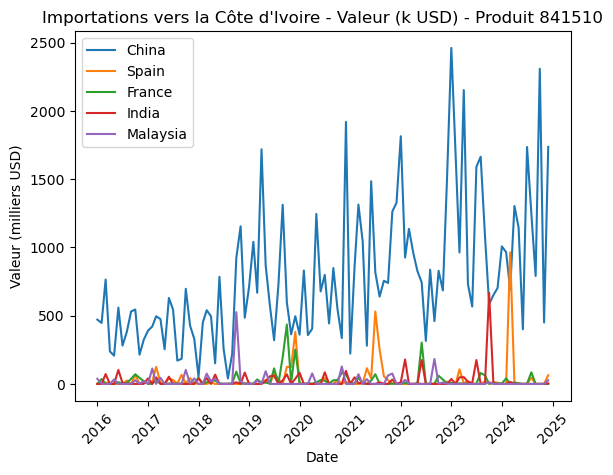

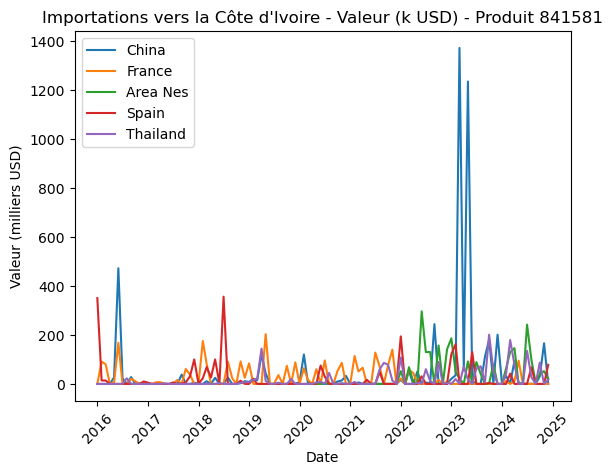

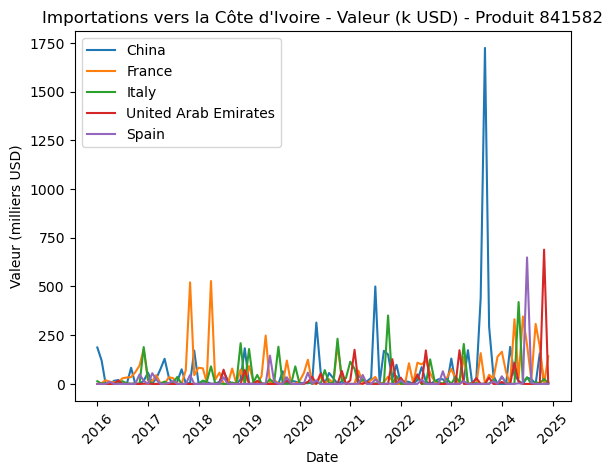

In [56]:
for product in ["841510", "841581", "841582"]:
    plt.figure()

    temp_prod = df_plot[df_plot["cmdCode"] == product].copy()
    top5 = top5_by_product[product]

    for country in top5:
        temp = temp_prod[temp_prod["partnerDesc"] == country].copy()
        temp = temp.sort_values("date")

        plt.plot(temp["date"], temp["value"], label=country)

    plt.title(f"Importations vers la Côte d'Ivoire - Valeur (k USD) - Produit {product}")
    plt.xlabel("Date")
    plt.ylabel("Valeur (milliers USD)")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

### Plot des quantités

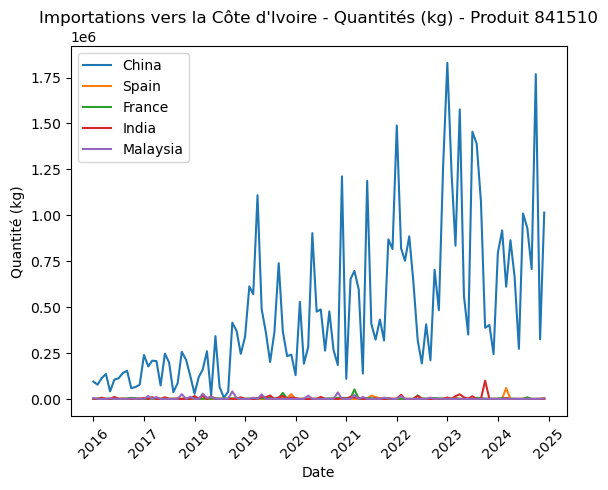

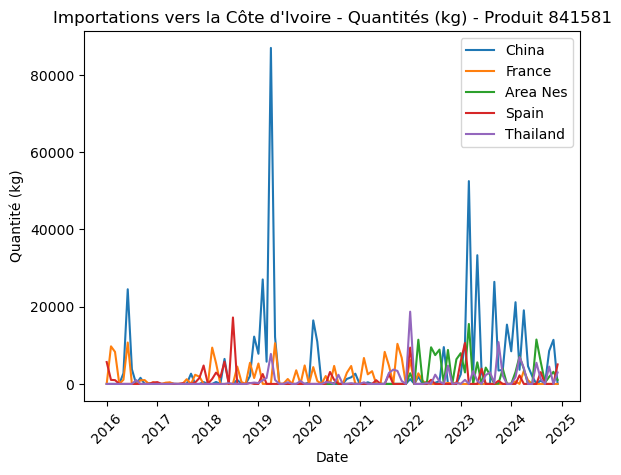

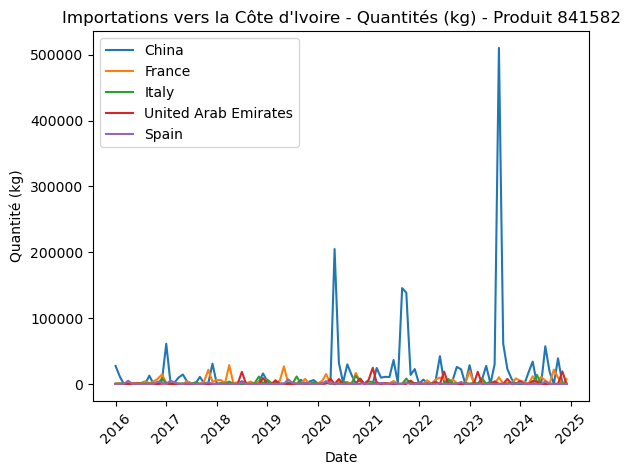

In [57]:
for product in ["841510", "841581", "841582"]:
    plt.figure()

    temp_prod = df_plot[df_plot["cmdCode"] == product].copy()
    top5 = top5_by_product[product]

    for country in top5:
        temp = temp_prod[temp_prod["partnerDesc"] == country].copy()
        temp = temp.sort_values("date")

        plt.plot(temp["date"], temp["quantity"], label=country)

    plt.title(f"Importations vers la Côte d'Ivoire - Quantités (kg) - Produit {product}")
    plt.xlabel("Date")
    plt.ylabel("Quantité (kg)")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

### Plot en valeurs unitaire

In [50]:
## Supprimer les outliers

df_plot = df_plot[df_plot["unit_value"] < 1000]

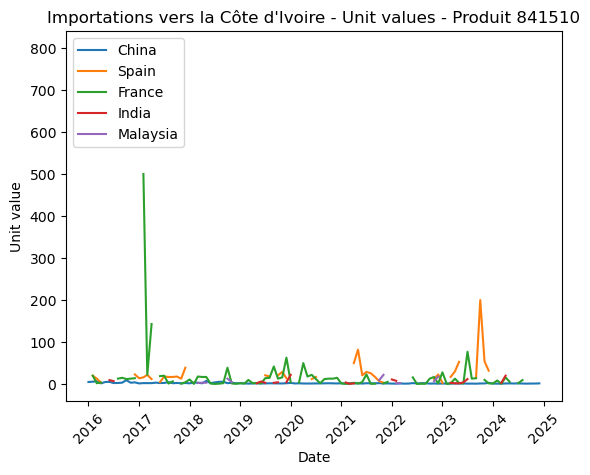

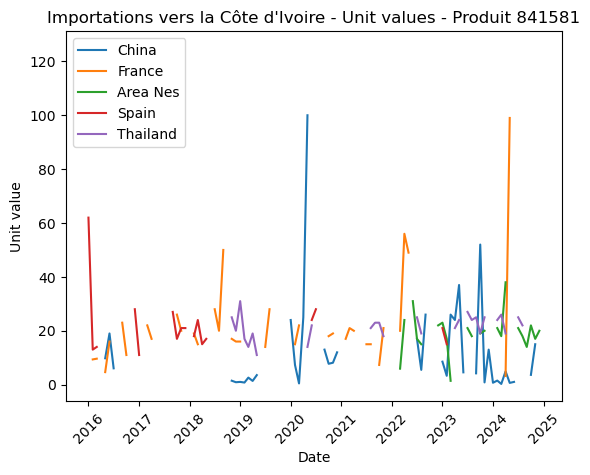

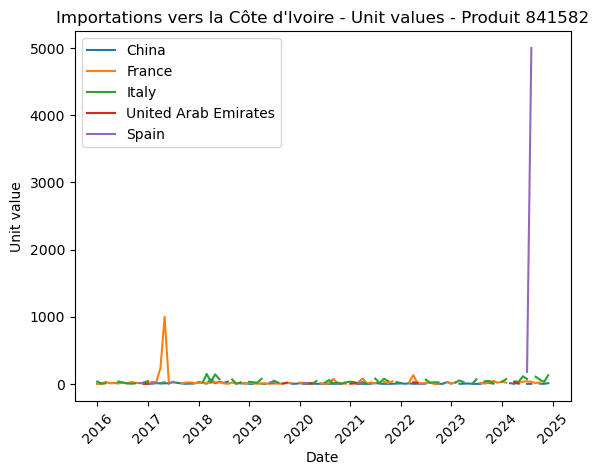

In [58]:
for product in ["841510", "841581", "841582"]:
    plt.figure()

    temp_prod = df_plot[df_plot["cmdCode"] == product].copy()
    top5 = top5_by_product[product]

    for country in top5:
        temp = temp_prod[temp_prod["partnerDesc"] == country].copy()
        temp = temp.sort_values("date")

        plt.plot(temp["date"], temp["unit_value"], label=country)

    plt.title(f"Importations vers la Côte d'Ivoire - Unit values - Produit {product}")
    plt.xlabel("Date")
    plt.ylabel("Unit value")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
'''
## Pour tout faire en même temps
def plot_top5_by_product(data, variable, ylabel, title_prefix):
    for product in ["841510", "841581", "841582"]:
        plt.figure()

        temp_prod = data[data["cmdCode"] == product].copy()
        top5 = top5_by_product[product]

        for country in top5:
            temp = temp_prod[temp_prod["partnerDesc"] == country].copy()
            temp = temp.sort_values("date")

            plt.plot(temp["date"], temp[variable], label=country)

        plt.title(f"{title_prefix} - Produit {product}")
        plt.xlabel("Date")
        plt.ylabel(ylabel)
        plt.legend()
        plt.xticks(rotation=45)
        plt.show()
'''

In [ ]:
'''
## plot_top5_by_product(
    data=df_plot,
    variable="value",
    ylabel="Valeur (milliers USD)",
    title_prefix="Importations vers la Côte d'Ivoire - Valeur"
)

plot_top5_by_product(
    data=df_plot,
    variable="quantity",
    ylabel="Quantité (kg)",
    title_prefix="Importations vers la Côte d'Ivoire - Quantités"
)

plot_top5_by_product(
    data=df_plot,
    variable="unit_value",
    ylabel="Unit value",
    title_prefix="Importations vers la Côte d'Ivoire - Unit values"
)
'''

### Analyse pour les pays africains

### Extraire de la base

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

df_af = merged_df.copy()

df_af["partnerDesc"] = df_af["partnerDesc"].astype(str).str.strip()
df_af["cmdCode"] = df_af["cmdCode"].astype(str).str.strip()
df_af["period"] = df_af["period"].astype(str).str.strip()
df_af["date"] = pd.to_datetime(df_af["period"], format="%Y%m", errors="coerce")

for col in ["value", "quantity", "unit_value"]:
    if col in df_af.columns:
        df_af[col] = pd.to_numeric(df_af[col], errors="coerce")

df_af = df_af[df_af["partnerDesc"] != "World"].copy()

### Liste de tous les pays présents par produit

In [60]:
countries_by_product = {
    product: sorted(
        df_af.loc[df_af["cmdCode"] == product, "partnerDesc"].dropna().unique().tolist()
    )
    for product in sorted(df_af["cmdCode"].unique())
}

for product, countries in countries_by_product.items():
    print(f"\nProduit {product} ({len(countries)} pays/partenaires) :")
    print(countries)


Produit 841510 (57 pays/partenaires) :
['Area Nes', 'Australia', 'Austria', 'Belgium', 'Benin', 'Brazil', 'Burkina Faso', 'Cameroon', 'Canada', 'China', 'Congo', 'Czech Republic', 'Egypt', 'Exporters', 'France', 'Free Zones', 'Gabon', 'Germany', 'Ghana', 'Guinea', 'Hong Kong, China', 'Hungary', 'India', 'Indonesia', 'Ireland', 'Israel', 'Italy', 'Japan', 'Korea, Republic of', 'Lebanon', 'Lithuania', 'Luxembourg', 'Malaysia', 'Mali', 'Mexico', 'Morocco', 'Netherlands', 'Nigeria', 'Norway', 'Poland', 'Portugal', 'Romania', 'Saudi Arabia', 'Senegal', 'Singapore', 'Slovakia', 'South Africa', 'Spain', 'Switzerland', 'Taipei, Chinese', 'Thailand', 'Tunisia', 'Türkiye', 'United Arab Emirates', 'United Kingdom', 'United States of America', 'Viet Nam']

Produit 841581 (35 pays/partenaires) :
['Algeria', 'Area Nes', 'Australia', 'Bahrain', 'Belgium', 'Brazil', 'Cameroon', 'Canada', 'China', 'Czech Republic', 'Exporters', 'France', 'Germany', 'Ghana', 'Greece', 'India', 'Ireland', 'Italy', 'Japa

### Définir la liste des pays africains

In [61]:
african_countries = {
    "Algeria", "Angola", "Benin", "Botswana", "Burkina Faso", "Burundi",
    "Cabo Verde", "Cameroon", "Central African Republic", "Chad", "Comoros",
    "Congo", "Democratic Republic of the Congo", "Djibouti", "Egypt",
    "Equatorial Guinea", "Eritrea", "Eswatini", "Ethiopia", "Gabon",
    "Gambia", "Ghana", "Guinea", "Guinea-Bissau", "Kenya", "Lesotho",
    "Liberia", "Libya", "Madagascar", "Malawi", "Mali", "Mauritania",
    "Mauritius", "Morocco", "Mozambique", "Namibia", "Niger", "Nigeria",
    "Rwanda", "Sao Tome and Principe", "Senegal", "Seychelles",
    "Sierra Leone", "Somalia", "South Africa", "South Sudan", "Sudan",
    "Tanzania", "Togo", "Tunisia", "Uganda", "Zambia", "Zimbabwe",
    "Côte d'Ivoire", "Ivory Coast"
}

### Voir quels pays africains sont présents dans ta base, par produit

In [62]:
african_countries_by_product = {
    product: sorted(
        set(countries_by_product[product]).intersection(african_countries)
    )
    for product in countries_by_product
}

for product, countries in african_countries_by_product.items():
    print(f"\nProduit {product} - pays africains présents ({len(countries)}) :")
    print(countries)


Produit 841510 - pays africains présents (14) :
['Benin', 'Burkina Faso', 'Cameroon', 'Congo', 'Egypt', 'Gabon', 'Ghana', 'Guinea', 'Mali', 'Morocco', 'Nigeria', 'Senegal', 'South Africa', 'Tunisia']

Produit 841581 - pays africains présents (7) :
['Algeria', 'Cameroon', 'Ghana', 'Morocco', 'Nigeria', 'Senegal', 'South Africa']

Produit 841582 - pays africains présents (14) :
['Algeria', 'Burkina Faso', 'Cameroon', 'Egypt', 'Gabon', 'Ghana', 'Mali', 'Mauritania', 'Morocco', 'Nigeria', 'Senegal', 'South Africa', 'Togo', 'Tunisia']


### Créer une base filtrée uniquement sur les pays africains

In [63]:
df_africa_only = df_af[df_af["partnerDesc"].isin(african_countries)].copy()

print(df_africa_only.head())
print(df_africa_only.shape)

  partnerDesc cmdCode  period  value  quantity  unit_value  uv_check  \
0     Algeria  841581  201906    0.0       0.0         NaN       NaN   
1     Algeria  841581  201907    0.0       0.0         NaN       NaN   
2     Algeria  841581  201908    0.0       0.0         NaN       NaN   
3     Algeria  841581  201909    0.0       0.0         NaN       NaN   
4     Algeria  841581  201910    6.0     398.0        15.0  0.015075   

        date  
0 2019-06-01  
1 2019-07-01  
2 2019-08-01  
3 2019-09-01  
4 2019-10-01  
(1251, 8)


### Fonction pour faire les plots par produit, seulement pour les pays africains présents

In [64]:
def plot_african_countries_by_product(data, variable, ylabel, title_prefix):
    for product in ["841510", "841581", "841582"]:
        temp_prod = data[data["cmdCode"] == product].copy()
        countries = african_countries_by_product.get(product, [])

        if len(countries) == 0:
            print(f"Aucun pays africain trouvé pour le produit {product}.")
            continue

        plt.figure()

        for country in countries:
            temp = temp_prod[temp_prod["partnerDesc"] == country].copy()
            temp = temp.sort_values("date")

            if temp.empty:
                continue

            plt.plot(temp["date"], temp[variable], label=country)

        plt.title(f"{title_prefix} - Produit {product} - Pays africains")
        plt.xlabel("Date")
        plt.ylabel(ylabel)
        plt.legend()
        plt.xticks(rotation=45)
        plt.show()

### Plot des valeurs pour les pays africains

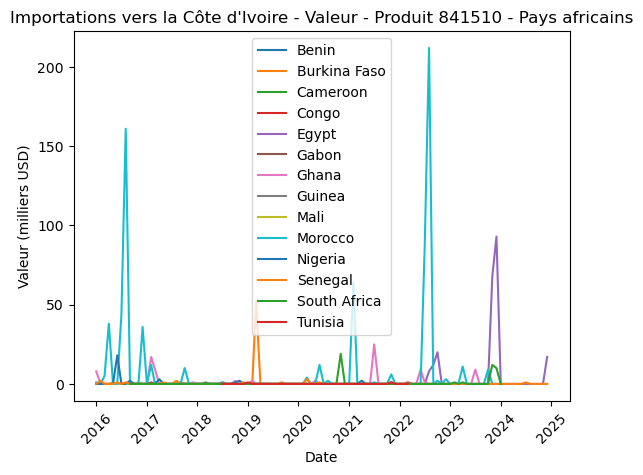

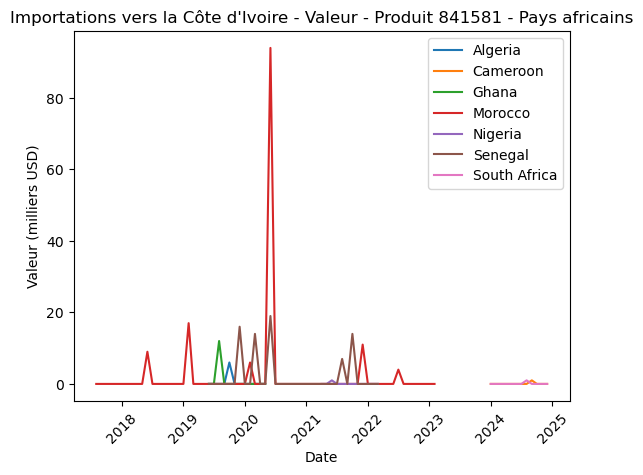

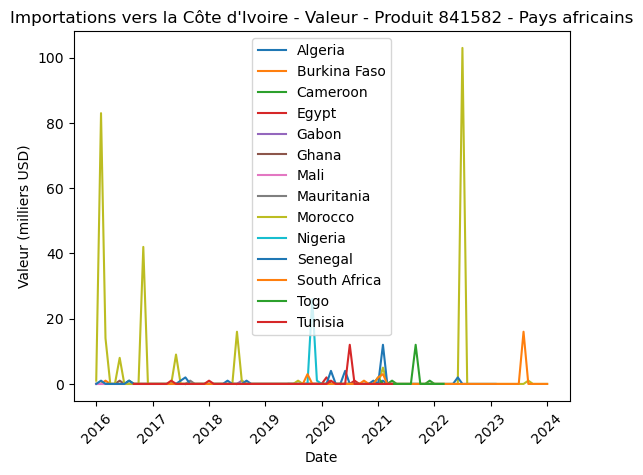

In [65]:
plot_african_countries_by_product(
    data=df_africa_only,
    variable="value",
    ylabel="Valeur (milliers USD)",
    title_prefix="Importations vers la Côte d'Ivoire - Valeur"
)

### Plot des quantités pour les pays africains

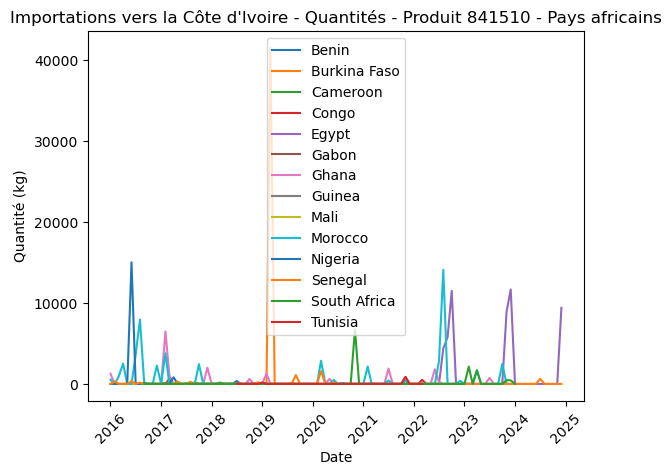

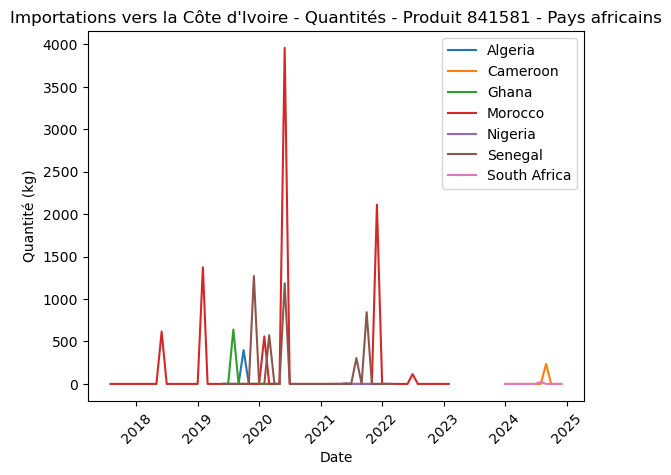

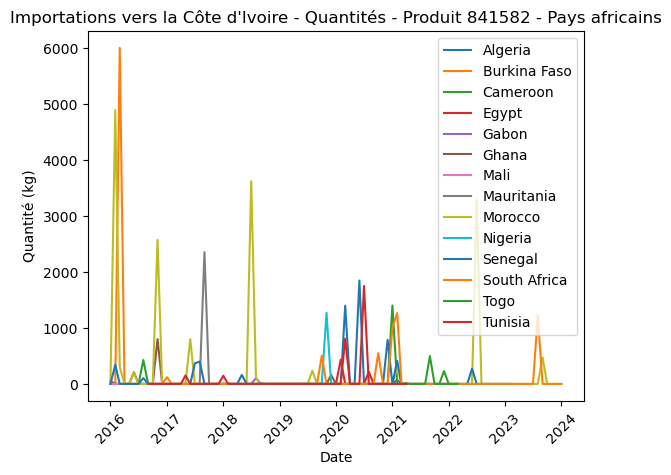

In [66]:
plot_african_countries_by_product(
    data=df_africa_only,
    variable="quantity",
    ylabel="Quantité (kg)",
    title_prefix="Importations vers la Côte d'Ivoire - Quantités"
)

### Plot des unit values pour les pays africains

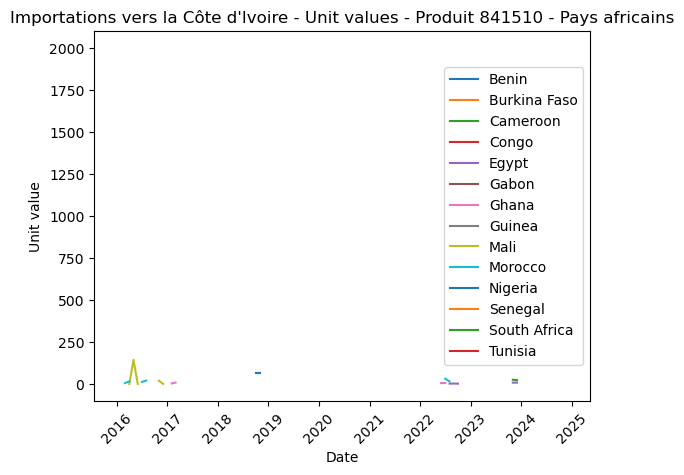

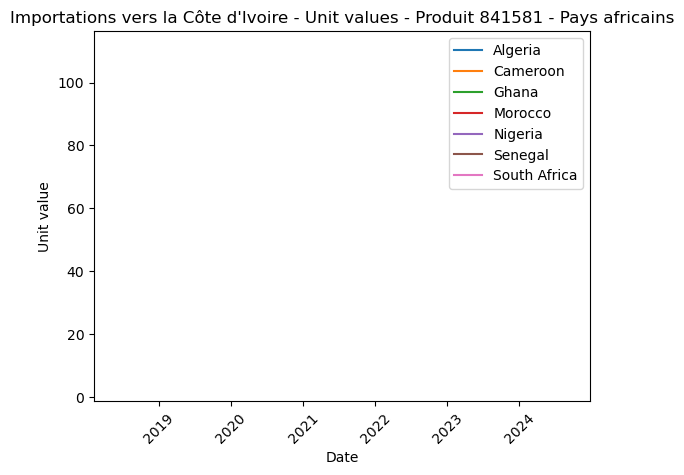

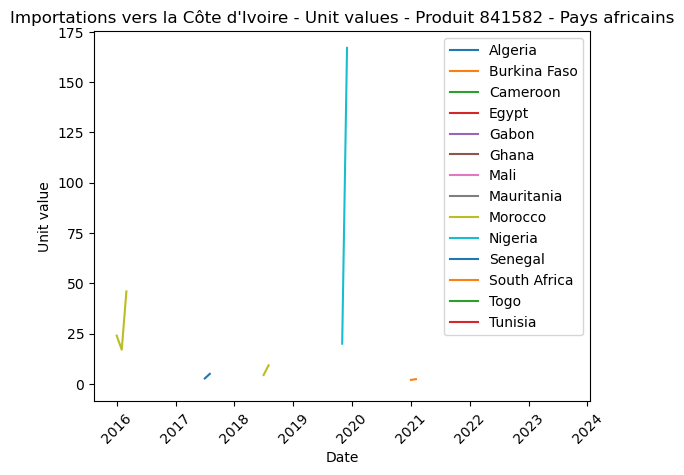

In [69]:
plot_african_countries_by_product(
    data=df_africa_only,
    variable="unit_value",
    ylabel="Unit value",
    title_prefix="Importations vers la Côte d'Ivoire - Unit values"
)

In [70]:
top5_african_by_product = {}

for product in ["841510", "841581", "841582"]:
    temp = df_africa_only[df_africa_only["cmdCode"] == product].copy()

    top5 = (
        temp.groupby("partnerDesc")["value"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .index.tolist()
    )

    top5_african_by_product[product] = top5

top5_african_by_product

{'841510': ['Morocco', 'Egypt', 'Ghana', 'Burkina Faso', 'South Africa'],
 '841581': ['Morocco', 'Senegal', 'Ghana', 'Algeria', 'Cameroon'],
 '841582': ['Morocco', 'Nigeria', 'Senegal', 'South Africa', 'Tunisia']}

In [71]:
def plot_top5_african_by_product(data, variable, ylabel, title_prefix):
    for product in ["841510", "841581", "841582"]:
        temp_prod = data[data["cmdCode"] == product].copy()
        countries = top5_african_by_product.get(product, [])

        if len(countries) == 0:
            print(f"Aucun pays africain trouvé pour le produit {product}.")
            continue

        plt.figure()

        for country in countries:
            temp = temp_prod[temp_prod["partnerDesc"] == country].copy()
            temp = temp.sort_values("date")

            if temp.empty:
                continue

            plt.plot(temp["date"], temp[variable], label=country)

        plt.title(f"{title_prefix} - Produit {product} - Top 5 pays africains")
        plt.xlabel("Date")
        plt.ylabel(ylabel)
        plt.legend()
        plt.xticks(rotation=45)
        plt.show()

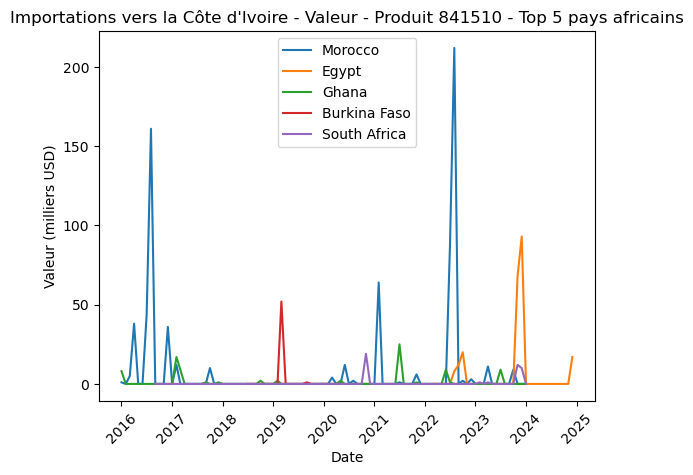

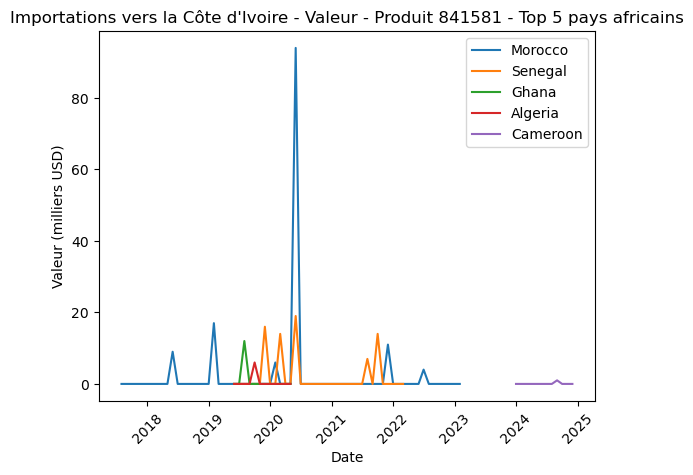

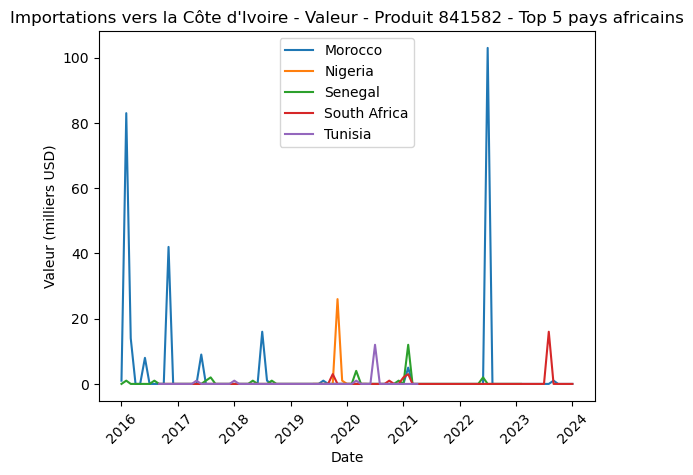

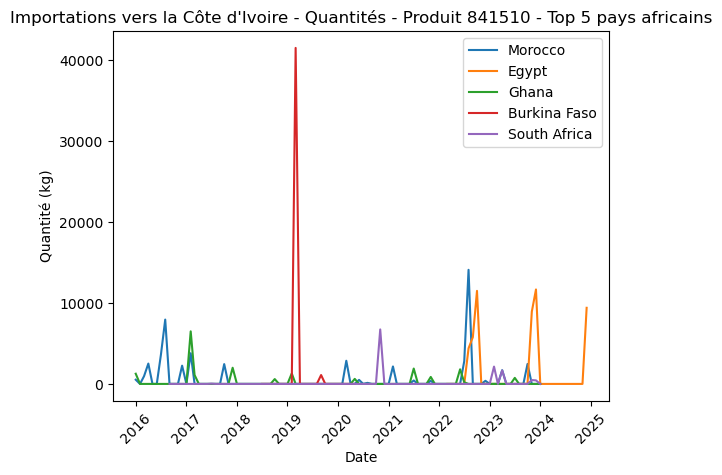

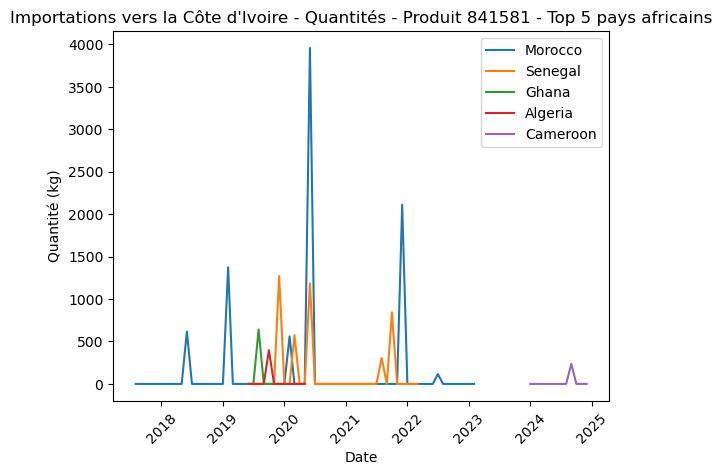

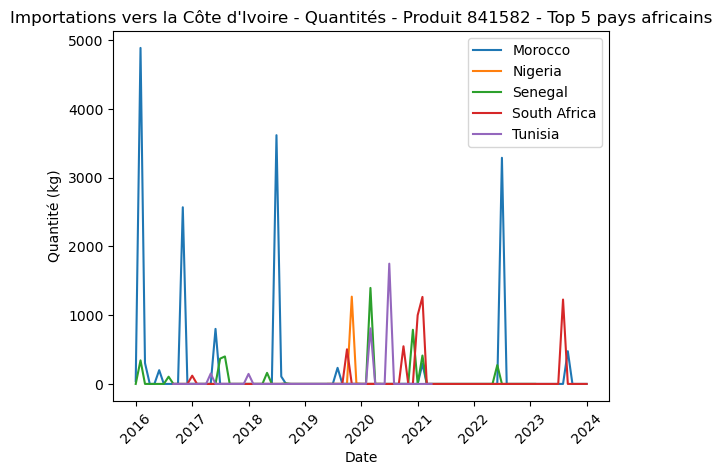

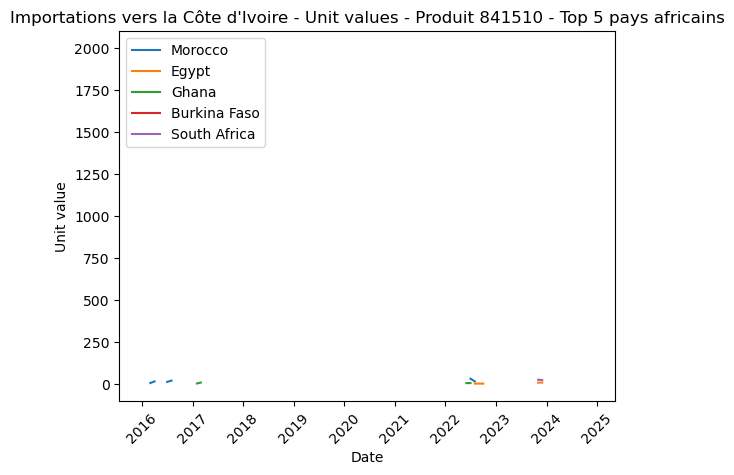

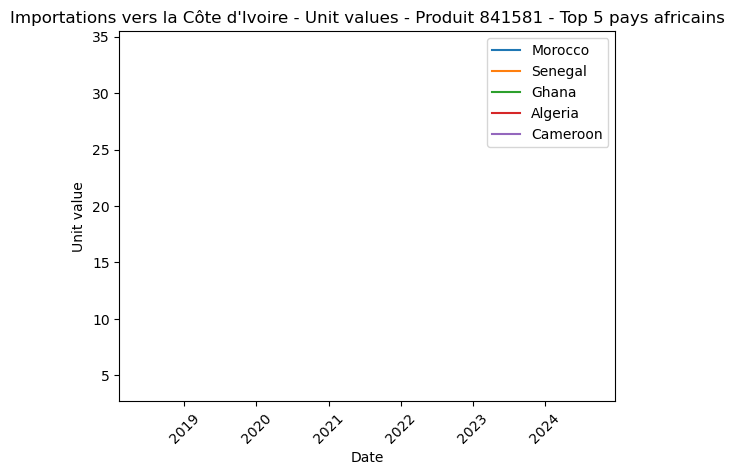

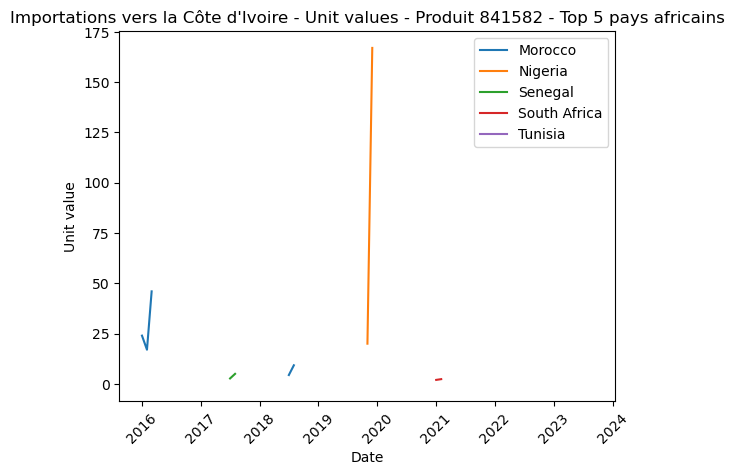

In [72]:
plot_top5_african_by_product(
    data=df_africa_only,
    variable="value",
    ylabel="Valeur (milliers USD)",
    title_prefix="Importations vers la Côte d'Ivoire - Valeur"
)

plot_top5_african_by_product(
    data=df_africa_only,
    variable="quantity",
    ylabel="Quantité (kg)",
    title_prefix="Importations vers la Côte d'Ivoire - Quantités"
)

plot_top5_african_by_product(
    data=df_africa_only,
    variable="unit_value",
    ylabel="Unit value",
    title_prefix="Importations vers la Côte d'Ivoire - Unit values"
)

### Liste des pays africains exportateurs par produit

In [73]:
rows = []

for product, countries in countries_by_product.items():
    for country in countries:
        rows.append({
            "cmdCode": product,
            "partnerDesc": country,
            "is_african": country in african_countries
        })

countries_df = pd.DataFrame(rows)
countries_df.to_excel(download_dir / "countries_by_product_africa_flag.xlsx", index=False)
countries_df.head()

,cmdCode,partnerDesc,is_african
0,841510,Area Nes,False
1,841510,Australia,False
2,841510,Austria,False
3,841510,Belgium,False
4,841510,Benin,True


## Analyse de la fiabilité des données de Trade Map

### Base de données ITC

In [4]:
import pandas as pd
import numpy as np
merged_df = pd.read_excel("CIV_AC_values_quantities_unitvalues.xlsx")
itc = merged_df.copy()

itc["cmdCode"] = itc["cmdCode"].astype(str).str.strip()
itc["partnerDesc"] = itc["partnerDesc"].astype(str).str.strip()
itc["period"] = itc["period"].astype(str).str.strip()

itc["value"] = pd.to_numeric(itc["value"], errors="coerce")
itc["quantity"] = pd.to_numeric(itc["quantity"], errors="coerce")

# enlever World pour l'analyse des anomalies pays
itc = itc[itc["partnerDesc"] != "World"].copy()

# date utile
itc["date"] = pd.to_datetime(itc["period"], format="%Y%m", errors="coerce")

print(itc.head())
print(itc.shape)

  partnerDesc cmdCode  period  value  quantity  unit_value       date
0     Algeria  841581  201906    0.0       0.0         NaN 2019-06-01
1     Algeria  841581  201907    0.0       0.0         NaN 2019-07-01
2     Algeria  841581  201908    0.0       0.0         NaN 2019-08-01
3     Algeria  841581  201909    0.0       0.0         NaN 2019-09-01
4     Algeria  841581  201910    6.0     398.0        15.0 2019-10-01
(7680, 7)


### Détection des valeurs aberrantes dans ITC

Je travaille par produit et sur chaque unité de données séparément. J’utilise la méthode des quantiles (IQR) sur le log des données.

In [5]:
def detect_outliers_iqr_log(df, var, group_col="cmdCode", k=1.5):
    out_parts = []

    for g, temp in df.groupby(group_col):
        sub = temp.copy()

        # garder seulement valeurs strictement positives pour le log
        sub = sub[sub[var].notna() & (sub[var] > 0)].copy()
        if sub.empty:
            continue

        sub[f"log_{var}"] = np.log(sub[var])

        q1 = sub[f"log_{var}"].quantile(0.25)
        q3 = sub[f"log_{var}"].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - k * iqr
        upper = q3 + k * iqr

        sub[f"{var}_outlier"] = (
            (sub[f"log_{var}"] < lower) |
            (sub[f"log_{var}"] > upper)
        )

        sub[f"{var}_lower_log_bound"] = lower
        sub[f"{var}_upper_log_bound"] = upper

        out_parts.append(sub)

    if not out_parts:
        return pd.DataFrame()

    return pd.concat(out_parts, ignore_index=True)

### Détection des valeurs ($) outliers

In [6]:
itc_value_out = detect_outliers_iqr_log(itc, var="value", group_col="cmdCode", k=1.5)

value_outliers = itc_value_out[itc_value_out["value_outlier"]].copy()

value_outliers = value_outliers[
    ["cmdCode", "partnerDesc", "period", "date", "value", "quantity",
     "log_value", "value_lower_log_bound", "value_upper_log_bound"]
].sort_values(["cmdCode", "period", "partnerDesc"])

print(value_outliers.head(20))
print(value_outliers.shape)

Empty DataFrame
Columns: [cmdCode, partnerDesc, period, date, value, quantity, log_value, value_lower_log_bound, value_upper_log_bound]
Index: []
(0, 9)


### Détection des quantités outliers

In [7]:
itc_qty_out = detect_outliers_iqr_log(itc, var="quantity", group_col="cmdCode", k=1.5)

qty_outliers = itc_qty_out[itc_qty_out["quantity_outlier"]].copy()

qty_outliers = qty_outliers[
    ["cmdCode", "partnerDesc", "period", "date", "value", "quantity",
     "log_quantity", "quantity_lower_log_bound", "quantity_upper_log_bound"]
].sort_values(["cmdCode", "period", "partnerDesc"])

print(qty_outliers.head(20))
print(qty_outliers.shape)

    cmdCode               partnerDesc  period       date   value   quantity  \
531  841510                      Mali  201604 2016-04-01     0.0        2.0   
533  841510                      Mali  201606 2016-06-01     0.0        3.0   
535  841510                      Mali  201612 2016-12-01     0.0        1.0   
213  841510                    France  201702 2017-02-01     1.0        2.0   
0    841510                  Area Nes  201709 2017-09-01     1.0        1.0   
310  841510                     Ghana  201709 2017-09-01     1.0        1.0   
500  841510                 Lithuania  201710 2017-10-01     1.0        2.0   
536  841510                      Mali  201807 2018-07-01     0.0        1.0   
448  841510                     Japan  201811 2018-11-01     3.0        2.0   
844  841510  United States of America  201903 2019-03-01     2.0        3.0   
96   841510                     China  201904 2019-04-01  1719.0  1109145.0   
109  841510                     China  202005 2020-0

### Merge des deux bases de outliers

In [8]:
value_flags = value_outliers[["cmdCode", "partnerDesc", "period", "date", "value", "quantity"]].copy()
value_flags["outlier_type"] = "value"

qty_flags = qty_outliers[["cmdCode", "partnerDesc", "period", "date", "value", "quantity"]].copy()
qty_flags["outlier_type"] = "quantity"

itc_outliers = pd.concat([value_flags, qty_flags], ignore_index=True)

itc_outliers = itc_outliers.sort_values(["cmdCode", "period", "partnerDesc", "outlier_type"]).reset_index(drop=True)

print(itc_outliers.head(30))
print(itc_outliers.shape)

   cmdCode               partnerDesc  period       date   value   quantity  \
0   841510                      Mali  201604 2016-04-01     0.0        2.0   
1   841510                      Mali  201606 2016-06-01     0.0        3.0   
2   841510                      Mali  201612 2016-12-01     0.0        1.0   
3   841510                    France  201702 2017-02-01     1.0        2.0   
4   841510                  Area Nes  201709 2017-09-01     1.0        1.0   
5   841510                     Ghana  201709 2017-09-01     1.0        1.0   
6   841510                 Lithuania  201710 2017-10-01     1.0        2.0   
7   841510                      Mali  201807 2018-07-01     0.0        1.0   
8   841510                     Japan  201811 2018-11-01     3.0        2.0   
9   841510  United States of America  201903 2019-03-01     2.0        3.0   
10  841510                     China  201904 2019-04-01  1719.0  1109145.0   
11  841510                     China  202005 2020-05-01  1246.0 

### Nombre d'outliers par produit

In [9]:
print(itc_outliers.groupby(["cmdCode", "outlier_type"]).size())

cmdCode  outlier_type
841510   quantity        40
841581   quantity         6
841582   quantity        10
dtype: int64


### Pays les plus concernés

In [10]:
print(
    itc_outliers.groupby(["cmdCode", "partnerDesc", "outlier_type"])
    .size()
    .sort_values(ascending=False)
    .head(30)
)

cmdCode  partnerDesc               outlier_type
841510   China                     quantity        25
         Mali                      quantity         5
841581   Italy                     quantity         2
         Japan                     quantity         2
841510   United States of America  quantity         2
         Area Nes                  quantity         2
841582   Ghana                     quantity         2
         China                     quantity         2
841510   Ghana                     quantity         1
         France                    quantity         1
         Lithuania                 quantity         1
         Japan                     quantity         1
         Nigeria                   quantity         1
         Morocco                   quantity         1
841581   Türkiye                   quantity         1
         Germany                   quantity         1
841582   Belgium                   quantity         1
         Area Nes                 

### Export de la table des outliers

In [12]:
itc_outliers.to_excel("ITC_outliers_values_quantities.xlsx", index=False)
itc_outliers.to_csv("ITC_outliers_values_quantities.csv", index=False)

### Base de Comtrade

In [13]:
final_df = pd.read_excel("CIV_AC_imports_2015_2025.xlsx")
comtrade = final_df.copy()

# garder uniquement ce qu’on veut
comtrade = comtrade[
    [
        "cmdCode",
        "partnerDesc",
        "partnerISO",
        "period",
        "primaryValue",
        "qty",
        "netWgt",
        "isReported",
        "isNetWgtEstimated",
        "isQtyEstimated",
        "legacyEstimationFlag"
    ]
]

# renommer
comtrade = comtrade.rename(columns={
    "primaryValue": "value_comtrade",
    "qty": "quantity_comtrade",
    "netWgt": "weight_kg_comtrade"
})

# types
comtrade["cmdCode"] = comtrade["cmdCode"].astype(str).str.strip()
comtrade["partnerDesc"] = comtrade["partnerDesc"].astype(str).str.strip()
comtrade["period"] = comtrade["period"].astype(str).str.strip()

for col in ["value_comtrade", "quantity_comtrade", "weight_kg_comtrade"]:
    comtrade[col] = pd.to_numeric(comtrade[col], errors="coerce")

# enlever world
comtrade = comtrade[comtrade["partnerISO"] != "W00"]

print(comtrade.head())

  cmdCode partnerDesc partnerISO  period  value_comtrade  quantity_comtrade  \
1  841510       China        CHN  201501      307827.405            837.407   
2  841510      France        FRA  201501        5830.981             15.862   
3  841510     Germany        DEU  201501         152.063              0.414   
4  841510       Italy        ITA  201501      134408.293            365.642   
5  841510     Senegal        SEN  201501          74.939              0.204   

   weight_kg_comtrade  isReported  isNetWgtEstimated  isQtyEstimated  \
1             95854.0       False              False            True   
2               614.0       False              False            True   
3               185.0       False              False            True   
4              4425.0       False              False            True   
5                50.0       False              False            True   

   legacyEstimationFlag  
1                     2  
2                     2  
3             

### Merge avec les outliers itc

In [14]:
compare_df = itc_outliers.merge(
    comtrade,
    on=["cmdCode", "partnerDesc", "period"],
    how="left"
)

print(compare_df.head(20))
print(compare_df.shape)

   cmdCode               partnerDesc  period       date   value   quantity  \
0   841510                      Mali  201604 2016-04-01     0.0        2.0   
1   841510                      Mali  201606 2016-06-01     0.0        3.0   
2   841510                      Mali  201612 2016-12-01     0.0        1.0   
3   841510                    France  201702 2017-02-01     1.0        2.0   
4   841510                  Area Nes  201709 2017-09-01     1.0        1.0   
5   841510                     Ghana  201709 2017-09-01     1.0        1.0   
6   841510                 Lithuania  201710 2017-10-01     1.0        2.0   
7   841510                      Mali  201807 2018-07-01     0.0        1.0   
8   841510                     Japan  201811 2018-11-01     3.0        2.0   
9   841510  United States of America  201903 2019-03-01     2.0        3.0   
10  841510                     China  201904 2019-04-01  1719.0  1109145.0   
11  841510                     China  202005 2020-05-01  1246.0 

Le merge échoue à partir de 2020 puisque les données ITC restent en mensuelles à partir de cette période alors que celles de Comtrade deviennent annuelles. 

### Je reprends une autre base des outliers ITC car je voudrais séparer les données mensuelles avant 2020 et celles après 2020 puisque je vais les aggréger au niveau annuel. 

### Nouvelle base des outliers ITC

In [15]:
itc_outliers2 = itc_outliers.copy()

itc_outliers2["cmdCode"] = itc_outliers2["cmdCode"].astype(str).str.strip()
itc_outliers2["partnerDesc"] = itc_outliers2["partnerDesc"].astype(str).str.strip()
itc_outliers2["period"] = itc_outliers2["period"].astype(str).str.strip()

itc_outliers2["value"] = pd.to_numeric(itc_outliers2["value"], errors="coerce")
itc_outliers2["quantity"] = pd.to_numeric(itc_outliers2["quantity"], errors="coerce")

# ici quantity dans ITC est le poids kg sur le site
itc_outliers2 = itc_outliers2.rename(columns={
    "value": "value_itc",
    "quantity": "weight_kg_itc"
})
      
itc_outliers2["year"] = itc_outliers2["period"].str[:4]
itc_outliers2["date"] = pd.to_datetime(itc_outliers2["period"], format="%Y%m", errors="coerce")

print(itc_outliers2.head())

  cmdCode partnerDesc  period       date  value_itc  weight_kg_itc  \
0  841510        Mali  201604 2016-04-01        0.0            2.0   
1  841510        Mali  201606 2016-06-01        0.0            3.0   
2  841510        Mali  201612 2016-12-01        0.0            1.0   
3  841510      France  201702 2017-02-01        1.0            2.0   
4  841510    Area Nes  201709 2017-09-01        1.0            1.0   

  outlier_type  year  
0     quantity  2016  
1     quantity  2016  
2     quantity  2016  
3     quantity  2017  
4     quantity  2017  


### Séparation pre and post 2020

In [16]:
itc_outliers_monthly = itc_outliers2[itc_outliers2["year"].astype(int) <= 2019].copy()
itc_outliers_annual_raw = itc_outliers2[itc_outliers2["year"].astype(int) >= 2020].copy()

### Aggrégation au niveau annuel post 2020 par produit, par année, par type d'outlier

In [17]:
itc_outliers_annual = (
    itc_outliers_annual_raw
    .groupby(["cmdCode", "partnerDesc", "year", "outlier_type"], as_index=False)
    .agg({
        "value_itc": "sum",
        "weight_kg_itc": "sum"
    })
)

# clé pratique
itc_outliers_annual["period"] = itc_outliers_annual["year"] + "01"

print(itc_outliers_annual.head())

  cmdCode partnerDesc  year outlier_type  value_itc  weight_kg_itc  period
0  841510    Area Nes  2024     quantity        0.0            2.0  202401
1  841510       China  2020     quantity     3166.0      2114162.0  202001
2  841510       China  2021     quantity     4076.0      2872599.0  202101
3  841510       China  2022     quantity     6344.0      5198779.0  202201
4  841510       China  2023     quantity    11597.0      9381995.0  202301


###  Je remets la base de Comtrade 

In [18]:
comtrade = final_df.copy()

comtrade = comtrade[
    [
        "cmdCode",
        "partnerDesc",
        "partnerISO",
        "freqCode",
        "period",
        "refYear",
        "refMonth",
        "primaryValue",
        "qty",
        "netWgt",
        "isReported",
        "isNetWgtEstimated",
        "isQtyEstimated",
        "legacyEstimationFlag"
    ]
].copy()

comtrade = comtrade.rename(columns={
    "primaryValue": "value_comtrade",
    "qty": "qty_comtrade",
    "netWgt": "weight_kg_comtrade"
})

comtrade["cmdCode"] = comtrade["cmdCode"].astype(str).str.strip()
comtrade["partnerDesc"] = comtrade["partnerDesc"].astype(str).str.strip()
comtrade["period"] = comtrade["period"].astype(str).str.strip()
comtrade["year"] = comtrade["refYear"].astype(str)

for col in ["value_comtrade", "qty_comtrade", "weight_kg_comtrade"]:
    comtrade[col] = pd.to_numeric(comtrade[col], errors="coerce")

comtrade = comtrade[comtrade["partnerISO"] != "W00"].copy()

print(comtrade.head())

  cmdCode partnerDesc partnerISO freqCode  period  refYear  refMonth  \
1  841510       China        CHN        M  201501     2015         1   
2  841510      France        FRA        M  201501     2015         1   
3  841510     Germany        DEU        M  201501     2015         1   
4  841510       Italy        ITA        M  201501     2015         1   
5  841510     Senegal        SEN        M  201501     2015         1   

   value_comtrade  qty_comtrade  weight_kg_comtrade  isReported  \
1      307827.405       837.407             95854.0       False   
2        5830.981        15.862               614.0       False   
3         152.063         0.414               185.0       False   
4      134408.293       365.642              4425.0       False   
5          74.939         0.204                50.0       False   

   isNetWgtEstimated  isQtyEstimated  legacyEstimationFlag  year  
1              False            True                     2  2015  
2              False          

### Séparer la base Comtrade mensuel et annuel

In [19]:
comtrade_monthly = comtrade[comtrade["freqCode"] == "M"].copy()
comtrade_annual = comtrade[comtrade["freqCode"] == "A"].copy()

### Merge Comtrade - ITC pour 2015-2019

In [20]:
compare_monthly = itc_outliers_monthly.merge(
    comtrade_monthly,
    on=["cmdCode", "partnerDesc", "period"],
    how="left",
    suffixes=("_itc", "_comtrade")
)

print(compare_monthly.columns)
print(compare_monthly.head())

Index(['cmdCode', 'partnerDesc', 'period', 'date', 'value_itc',
       'weight_kg_itc', 'outlier_type', 'year_itc', 'partnerISO', 'freqCode',
       'refYear', 'refMonth', 'value_comtrade', 'qty_comtrade',
       'weight_kg_comtrade', 'isReported', 'isNetWgtEstimated',
       'isQtyEstimated', 'legacyEstimationFlag', 'year_comtrade'],
      dtype='object')
  cmdCode partnerDesc  period       date  value_itc  weight_kg_itc  \
0  841510        Mali  201604 2016-04-01        0.0            2.0   
1  841510        Mali  201606 2016-06-01        0.0            3.0   
2  841510        Mali  201612 2016-12-01        0.0            1.0   
3  841510      France  201702 2017-02-01        1.0            2.0   
4  841510    Area Nes  201709 2017-09-01        1.0            1.0   

  outlier_type year_itc partnerISO freqCode  refYear  refMonth  \
0     quantity     2016        MLI        M   2016.0       4.0   
1     quantity     2016        MLI        M   2016.0       6.0   
2     quantity     201

### Merge Comtrade - ITC pour 2020-2024 
Je merge ici sur l'année directement

In [21]:
compare_annual = itc_outliers_annual.merge(
    comtrade_annual,
    on=["cmdCode", "partnerDesc", "year"],
    how="left",
    suffixes=("_itc", "_comtrade")
)

print(compare_annual.columns)
print(compare_annual.head())

Index(['cmdCode', 'partnerDesc', 'year', 'outlier_type', 'value_itc',
       'weight_kg_itc', 'period_itc', 'partnerISO', 'freqCode',
       'period_comtrade', 'refYear', 'refMonth', 'value_comtrade',
       'qty_comtrade', 'weight_kg_comtrade', 'isReported', 'isNetWgtEstimated',
       'isQtyEstimated', 'legacyEstimationFlag'],
      dtype='object')
  cmdCode partnerDesc  year outlier_type  value_itc  weight_kg_itc period_itc  \
0  841510    Area Nes  2024     quantity        0.0            2.0     202401   
1  841510       China  2020     quantity     3166.0      2114162.0     202001   
2  841510       China  2021     quantity     4076.0      2872599.0     202101   
3  841510       China  2022     quantity     6344.0      5198779.0     202201   
4  841510       China  2023     quantity    11597.0      9381995.0     202301   

  partnerISO freqCode period_comtrade  refYear  refMonth  value_comtrade  \
0        NaN      NaN             NaN      NaN       NaN             NaN   
1       

In [22]:
if "year_itc" in compare_monthly.columns:
    compare_monthly = compare_monthly.rename(columns={"year_itc": "year"})
if "year_itc" in compare_annual.columns:
    compare_annual = compare_annual.rename(columns={"year_itc": "year"})

if "year" not in compare_monthly.columns and "period" in compare_monthly.columns:
    compare_monthly["year"] = compare_monthly["period"].astype(str).str[:4]

if "year" not in compare_annual.columns and "period" in compare_annual.columns:
    compare_annual["year"] = compare_annual["period"].astype(str).str[:4]

### Garder les colonnes nécessaires pour mettre les deux périodes ensemble

In [23]:
cols_keep = [
    "cmdCode",
    "partnerDesc",
    "period",
    "year",
    "outlier_type",
    "value_itc",
    "weight_kg_itc",
    "partnerISO",
    "value_comtrade",
    "qty_comtrade",
    "weight_kg_comtrade",
    "isReported",
    "isNetWgtEstimated",
    "isQtyEstimated",
    "legacyEstimationFlag"
]

compare_monthly2 = compare_monthly[[c for c in cols_keep if c in compare_monthly.columns]].copy()
compare_annual2 = compare_annual[[c for c in cols_keep if c in compare_annual.columns]].copy()

compare_all = pd.concat([compare_monthly2, compare_annual2], ignore_index=True)

print(compare_all.head(20))
print(compare_all.shape)
print(compare_all.columns)

   cmdCode               partnerDesc  period  year outlier_type  value_itc  \
0   841510                      Mali  201604  2016     quantity        0.0   
1   841510                      Mali  201606  2016     quantity        0.0   
2   841510                      Mali  201612  2016     quantity        0.0   
3   841510                    France  201702  2017     quantity        1.0   
4   841510                  Area Nes  201709  2017     quantity        1.0   
5   841510                     Ghana  201709  2017     quantity        1.0   
6   841510                 Lithuania  201710  2017     quantity        1.0   
7   841510                      Mali  201807  2018     quantity        0.0   
8   841510                     Japan  201811  2018     quantity        3.0   
9   841510  United States of America  201903  2019     quantity        2.0   
10  841510                     China  201904  2019     quantity     1719.0   
11  841581                     Italy  201907  2019     quantity 

### Trouver les écrats entre les valeurs caractéristiques ITC et Comtrade des outliers 

In [24]:
compare_all["value_gap"] = 1000*compare_all["value_itc"] - compare_all["value_comtrade"]
compare_all["weight_gap"] = compare_all["weight_kg_itc"] - compare_all["weight_kg_comtrade"]

compare_all["value_ratio"] = 1000*compare_all["value_itc"] / compare_all["value_comtrade"]
compare_all["weight_ratio"] = compare_all["weight_kg_itc"] / compare_all["weight_kg_comtrade"]

print(compare_all.head(20))

   cmdCode               partnerDesc  period  year outlier_type  value_itc  \
0   841510                      Mali  201604  2016     quantity        0.0   
1   841510                      Mali  201606  2016     quantity        0.0   
2   841510                      Mali  201612  2016     quantity        0.0   
3   841510                    France  201702  2017     quantity        1.0   
4   841510                  Area Nes  201709  2017     quantity        1.0   
5   841510                     Ghana  201709  2017     quantity        1.0   
6   841510                 Lithuania  201710  2017     quantity        1.0   
7   841510                      Mali  201807  2018     quantity        0.0   
8   841510                     Japan  201811  2018     quantity        3.0   
9   841510  United States of America  201903  2019     quantity        2.0   
10  841510                     China  201904  2019     quantity     1719.0   
11  841581                     Italy  201907  2019     quantity 

### Je vais essayer de trouver les outliers pour lesquels la différence entre les caractéristques de ITC et celles de Comtrade sont les plus élevées

In [25]:
print(compare_all[
    [
        "cmdCode", "partnerDesc", "year", "period", "outlier_type",
        "value_itc", "value_comtrade", "value_ratio",
        "weight_kg_itc", "weight_kg_comtrade", "weight_ratio",
        "qty_comtrade"
    ]
].sort_values("value_ratio", ascending=False).head(30))

   cmdCode partnerDesc  year  period outlier_type  value_itc  value_comtrade  \
10  841510       China  2019  201904     quantity     1719.0    8.936645e+05   
3   841510      France  2017  201702     quantity        1.0    7.048270e+02   
14  841582      France  2017  201705     quantity        1.0    7.318840e+02   
6   841510   Lithuania  2017  201710     quantity        1.0    7.957950e+02   
26  841510     Nigeria  2021     NaN     quantity        2.0    1.772145e+03   
8   841510       Japan  2018  201811     quantity        3.0    2.666950e+03   
15  841582     Belgium  2019  201902     quantity        1.0    9.197710e+02   
11  841581       Italy  2019  201907     quantity        2.0    1.847059e+03   
5   841510       Ghana  2017  201709     quantity        1.0    9.624470e+02   
35  841582     Denmark  2020     NaN     quantity        1.0    1.011450e+03   
12  841581       Italy  2019  201911     quantity        1.0    1.106337e+03   
22  841510       China  2023     NaN    

### Les outliers ont-ils des caractéristiques estimées chez Comtrade?

In [26]:
print(compare_all[
    [
        "cmdCode", "partnerDesc", "year", "period", "outlier_type",
        "value_itc", "value_comtrade",
        "weight_kg_itc", "weight_kg_comtrade",
        "qty_comtrade",
        "isReported", "isQtyEstimated", "isNetWgtEstimated", "legacyEstimationFlag"
    ]
].head(30))

   cmdCode               partnerDesc  year  period outlier_type  value_itc  \
0   841510                      Mali  2016  201604     quantity        0.0   
1   841510                      Mali  2016  201606     quantity        0.0   
2   841510                      Mali  2016  201612     quantity        0.0   
3   841510                    France  2017  201702     quantity        1.0   
4   841510                  Area Nes  2017  201709     quantity        1.0   
5   841510                     Ghana  2017  201709     quantity        1.0   
6   841510                 Lithuania  2017  201710     quantity        1.0   
7   841510                      Mali  2018  201807     quantity        0.0   
8   841510                     Japan  2018  201811     quantity        3.0   
9   841510  United States of America  2019  201903     quantity        2.0   
10  841510                     China  2019  201904     quantity     1719.0   
11  841581                     Italy  2019  201907     quantity 

### Exportations de la base de comparaison

In [28]:
compare_all.to_excel("ITC_vs_Comtrade_outliers_comparison.xlsx", index=False)
compare_all.to_csv("ITC_vs_Comtrade_outliers_comparison.csv", index=False)

## Corrélation entre les données ITC et Comtrade

### Je rappelle la base complète ITC

In [29]:
import pandas as pd
import numpy as np

itc_full = merged_df.copy()

itc_full["cmdCode"] = itc_full["cmdCode"].astype(str).str.strip()
itc_full["partnerDesc"] = itc_full["partnerDesc"].astype(str).str.strip()
itc_full["period"] = itc_full["period"].astype(str).str.strip()

itc_full["value"] = pd.to_numeric(itc_full["value"], errors="coerce")
itc_full["quantity"] = pd.to_numeric(itc_full["quantity"], errors="coerce")

# renommage clair
itc_full = itc_full.rename(columns={
    "value": "value_itc",
    "quantity": "weight_kg_itc"
})

itc_full["year"] = itc_full["period"].str[:4]
itc_full["date"] = pd.to_datetime(itc_full["period"], format="%Y%m", errors="coerce")

# enlever le monde
itc_full = itc_full[itc_full["partnerDesc"] != "World"].copy()

print(itc_full.head())
print(itc_full.shape)

  partnerDesc cmdCode  period  value_itc  weight_kg_itc  unit_value  year  \
0     Algeria  841581  201906        0.0            0.0         NaN  2019   
1     Algeria  841581  201907        0.0            0.0         NaN  2019   
2     Algeria  841581  201908        0.0            0.0         NaN  2019   
3     Algeria  841581  201909        0.0            0.0         NaN  2019   
4     Algeria  841581  201910        6.0          398.0        15.0  2019   

        date  
0 2019-06-01  
1 2019-07-01  
2 2019-08-01  
3 2019-09-01  
4 2019-10-01  
(7680, 8)


### Je rappelle la base Comtrade

In [30]:
comtrade_full = final_df.copy()

comtrade_full = comtrade_full[
    [
        "cmdCode",
        "partnerDesc",
        "partnerISO",
        "freqCode",
        "period",
        "refYear",
        "refMonth",
        "primaryValue",
        "qty",
        "netWgt",
        "isReported",
        "isNetWgtEstimated",
        "isQtyEstimated",
        "legacyEstimationFlag"
    ]
].copy()

comtrade_full = comtrade_full.rename(columns={
    "primaryValue": "value_comtrade",
    "qty": "qty_comtrade",
    "netWgt": "weight_kg_comtrade"
})

comtrade_full["cmdCode"] = comtrade_full["cmdCode"].astype(str).str.strip()
comtrade_full["partnerDesc"] = comtrade_full["partnerDesc"].astype(str).str.strip()
comtrade_full["period"] = comtrade_full["period"].astype(str).str.strip()
comtrade_full["year"] = comtrade_full["refYear"].astype(str)

for col in ["value_comtrade", "qty_comtrade", "weight_kg_comtrade"]:
    comtrade_full[col] = pd.to_numeric(comtrade_full[col], errors="coerce")

comtrade_full = comtrade_full[comtrade_full["partnerISO"] != "W00"].copy()

print(comtrade_full.head())
print(comtrade_full.shape)

  cmdCode partnerDesc partnerISO freqCode  period  refYear  refMonth  \
1  841510       China        CHN        M  201501     2015         1   
2  841510      France        FRA        M  201501     2015         1   
3  841510     Germany        DEU        M  201501     2015         1   
4  841510       Italy        ITA        M  201501     2015         1   
5  841510     Senegal        SEN        M  201501     2015         1   

   value_comtrade  qty_comtrade  weight_kg_comtrade  isReported  \
1      307827.405       837.407             95854.0       False   
2        5830.981        15.862               614.0       False   
3         152.063         0.414               185.0       False   
4      134408.293       365.642              4425.0       False   
5          74.939         0.204                50.0       False   

   isNetWgtEstimated  isQtyEstimated  legacyEstimationFlag  year  
1              False            True                     2  2015  
2              False          

### Séparer les données mensuelles (pré-2020) des annuelles (post-2019)

In [31]:
### ITC
itc_full_monthly = itc_full[itc_full["year"].astype(int) <= 2019].copy()
itc_full_annual_raw = itc_full[itc_full["year"].astype(int) >= 2020].copy()

itc_full_annual = (
    itc_full_annual_raw
    .groupby(["cmdCode", "partnerDesc", "year"], as_index=False)
    .agg({
        "value_itc": "sum",
        "weight_kg_itc": "sum"
    })
)

itc_full_annual["period"] = itc_full_annual["year"] + "01"

### Comtrade
comtrade_monthly = comtrade_full[comtrade_full["freqCode"] == "M"].copy()
comtrade_annual = comtrade_full[comtrade_full["freqCode"] == "A"].copy()

### Merge des deux bases

#### 2015-2019 : Mensuel

In [32]:
full_compare_monthly = itc_full_monthly.merge(
    comtrade_monthly,
    on=["cmdCode", "partnerDesc", "period"],
    how="left",
    suffixes=("_itc", "_comtrade")
)

if "year_itc" in full_compare_monthly.columns:
    full_compare_monthly = full_compare_monthly.rename(columns={"year_itc": "year"})
if "year" not in full_compare_monthly.columns:
    full_compare_monthly["year"] = full_compare_monthly["period"].str[:4]

#### 2020-2024 : Annuel

In [33]:
full_compare_annual = itc_full_annual.merge(
    comtrade_annual,
    on=["cmdCode", "partnerDesc", "year"],
    how="left",
    suffixes=("_itc", "_comtrade")
)

if "year_itc" in full_compare_annual.columns:
    full_compare_annual = full_compare_annual.rename(columns={"year_itc": "year"})
if "year" not in full_compare_annual.columns:
    full_compare_annual["year"] = full_compare_annual["period"].str[:4]

#### Association des deux périodes

In [34]:
cols_keep_full = [
    "cmdCode",
    "partnerDesc",
    "period",
    "year",
    "partnerISO",
    "value_itc",
    "weight_kg_itc",
    "value_comtrade",
    "qty_comtrade",
    "weight_kg_comtrade",
    "isReported",
    "isNetWgtEstimated",
    "isQtyEstimated",
    "legacyEstimationFlag"
]

full_compare_monthly2 = full_compare_monthly[[c for c in cols_keep_full if c in full_compare_monthly.columns]].copy()
full_compare_annual2 = full_compare_annual[[c for c in cols_keep_full if c in full_compare_annual.columns]].copy()

full_compare = pd.concat([full_compare_monthly2, full_compare_annual2], ignore_index=True)

print(full_compare.head())
print(full_compare.shape)

  cmdCode partnerDesc  period  year partnerISO  value_itc  weight_kg_itc  \
0  841581     Algeria  201906  2019        NaN        0.0            0.0   
1  841581     Algeria  201907  2019        NaN        0.0            0.0   
2  841581     Algeria  201908  2019        NaN        0.0            0.0   
3  841581     Algeria  201909  2019        NaN        0.0            0.0   
4  841581     Algeria  201910  2019        DZA        6.0          398.0   

   value_comtrade  qty_comtrade  weight_kg_comtrade isReported  \
0             NaN           NaN                 NaN        NaN   
1             NaN           NaN                 NaN        NaN   
2             NaN           NaN                 NaN        NaN   
3             NaN           NaN                 NaN        NaN   
4          6071.2           0.0               398.0      False   

  isNetWgtEstimated isQtyEstimated  legacyEstimationFlag  
0               NaN            NaN                   NaN  
1               NaN         

### Corrélation sur toute la base

#### Base 

In [35]:
corr_full = full_compare.dropna(subset=[
    "value_itc", "value_comtrade",
    "weight_kg_itc", "weight_kg_comtrade"
]).copy()

print(corr_full.shape)

(1252, 14)


#### Corrélation sur les données brutes

In [36]:
corr_matrix_full = corr_full[
    ["value_itc", "value_comtrade", "weight_kg_itc", "weight_kg_comtrade"]
].corr()

print(corr_matrix_full)

                    value_itc  value_comtrade  weight_kg_itc  \
value_itc            1.000000        0.998830       0.978382   
value_comtrade       0.998830        1.000000       0.977099   
weight_kg_itc        0.978382        0.977099       1.000000   
weight_kg_comtrade   0.976824        0.977922       0.998664   

                    weight_kg_comtrade  
value_itc                     0.976824  
value_comtrade                0.977922  
weight_kg_itc                 0.998664  
weight_kg_comtrade            1.000000  


#### Corrélations sur les données en log

In [37]:
corr_full["log_value_itc"] = np.log1p(corr_full["value_itc"])
corr_full["log_value_comtrade"] = np.log1p(corr_full["value_comtrade"])

corr_full["log_weight_itc"] = np.log1p(corr_full["weight_kg_itc"])
corr_full["log_weight_comtrade"] = np.log1p(corr_full["weight_kg_comtrade"])

corr_matrix_full_log = corr_full[
    ["log_value_itc", "log_value_comtrade", "log_weight_itc", "log_weight_comtrade"]
].corr()

print(corr_matrix_full_log)

                     log_value_itc  log_value_comtrade  log_weight_itc  \
log_value_itc             1.000000            0.966711        0.860803   
log_value_comtrade        0.966711            1.000000        0.895130   
log_weight_itc            0.860803            0.895130        1.000000   
log_weight_comtrade       0.828744            0.827663        0.878884   

                     log_weight_comtrade  
log_value_itc                   0.828744  
log_value_comtrade              0.827663  
log_weight_itc                  0.878884  
log_weight_comtrade             1.000000  


### Corrélations sur la base des outliers
Je rappelle la base compare_all constituée plus haut


In [38]:
### sur les données brutes
corr_outliers = compare_all.dropna(subset=[
    "value_itc", "value_comtrade",
    "weight_kg_itc", "weight_kg_comtrade"
]).copy()

corr_matrix_outliers = corr_outliers[
    ["value_itc", "value_comtrade", "weight_kg_itc", "weight_kg_comtrade"]
].corr()

print(corr_matrix_outliers)

### sur les données en log
corr_outliers["log_value_itc"] = np.log1p(corr_outliers["value_itc"])
corr_outliers["log_value_comtrade"] = np.log1p(corr_outliers["value_comtrade"])

corr_outliers["log_weight_itc"] = np.log1p(corr_outliers["weight_kg_itc"])
corr_outliers["log_weight_comtrade"] = np.log1p(corr_outliers["weight_kg_comtrade"])

corr_matrix_outliers_log = corr_outliers[
    ["log_value_itc", "log_value_comtrade", "log_weight_itc", "log_weight_comtrade"]
].corr()

print(corr_matrix_outliers_log)

                    value_itc  value_comtrade  weight_kg_itc  \
value_itc            1.000000        0.953728       0.996976   
value_comtrade       0.953728        1.000000       0.946263   
weight_kg_itc        0.996976        0.946263       1.000000   
weight_kg_comtrade   0.975711        0.992576       0.971770   

                    weight_kg_comtrade  
value_itc                     0.975711  
value_comtrade                0.992576  
weight_kg_itc                 0.971770  
weight_kg_comtrade            1.000000  
                     log_value_itc  log_value_comtrade  log_weight_itc  \
log_value_itc             1.000000            0.878623        0.986919   
log_value_comtrade        0.878623            1.000000        0.835276   
log_weight_itc            0.986919            0.835276        1.000000   
log_weight_comtrade       0.894290            0.970492        0.878036   

                     log_weight_comtrade  
log_value_itc                   0.894290  
log_value_comtrad

#### Faisons un tableau comparatif des corrélations

In [39]:
summary_corr = pd.DataFrame({
    "full_base": [
        corr_matrix_full.loc["value_itc", "value_comtrade"],
        corr_matrix_full.loc["weight_kg_itc", "weight_kg_comtrade"],
        corr_matrix_full_log.loc["log_value_itc", "log_value_comtrade"],
        corr_matrix_full_log.loc["log_weight_itc", "log_weight_comtrade"]
    ],
    "outliers_only": [
        corr_matrix_outliers.loc["value_itc", "value_comtrade"],
        corr_matrix_outliers.loc["weight_kg_itc", "weight_kg_comtrade"],
        corr_matrix_outliers_log.loc["log_value_itc", "log_value_comtrade"],
        corr_matrix_outliers_log.loc["log_weight_itc", "log_weight_comtrade"]
    ]
}, index=[
    "value_correlation",
    "weight_correlation",
    "log_value_correlation",
    "log_weight_correlation"
])

print(summary_corr)

                        full_base  outliers_only
value_correlation        0.998830       0.953728
weight_correlation       0.998664       0.971770
log_value_correlation    0.966711       0.878623
log_weight_correlation   0.878884       0.878036


### Faisons un graphique pour voir la similitude entre les données des deux bases

#### Sur toute la base en données brutes

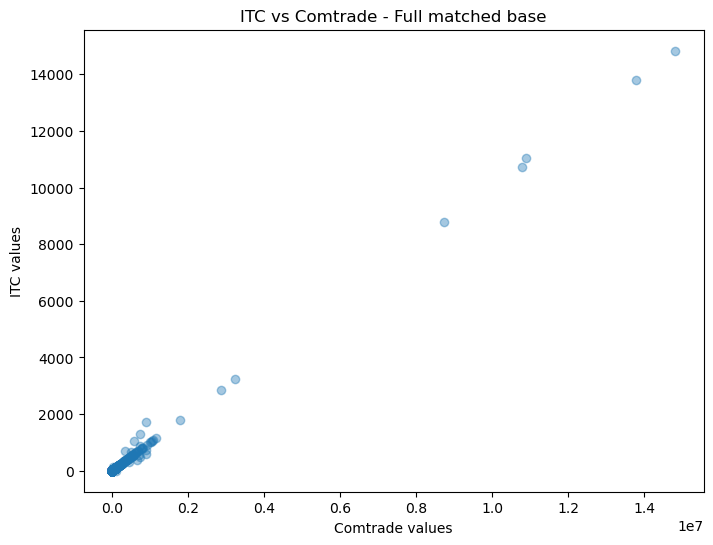

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(corr_full["value_comtrade"], corr_full["value_itc"], alpha=0.4)

plt.xlabel("Comtrade values")
plt.ylabel("ITC values")
plt.title("ITC vs Comtrade - Full matched base")
plt.show()

#### Sur toute la base en transformation log

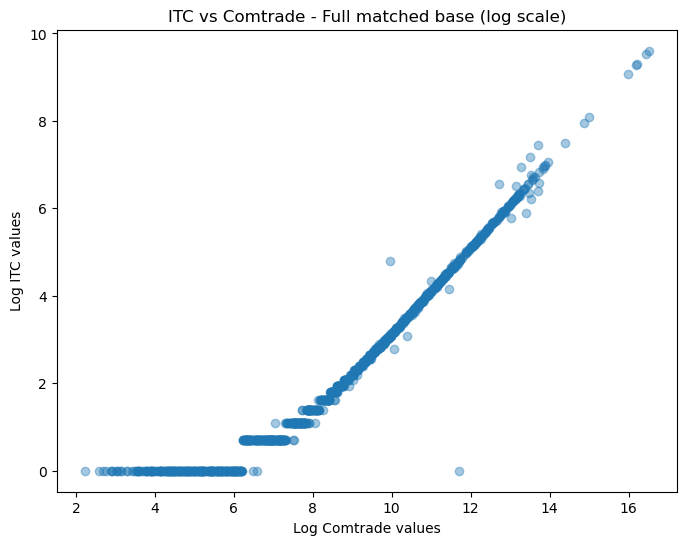

In [41]:
plt.figure(figsize=(8,6))
plt.scatter(corr_full["log_value_comtrade"], corr_full["log_value_itc"], alpha=0.4)

plt.xlabel("Log Comtrade values")
plt.ylabel("Log ITC values")
plt.title("ITC vs Comtrade - Full matched base (log scale)")
plt.show()

#### Sur la base des outliers en transformation log 

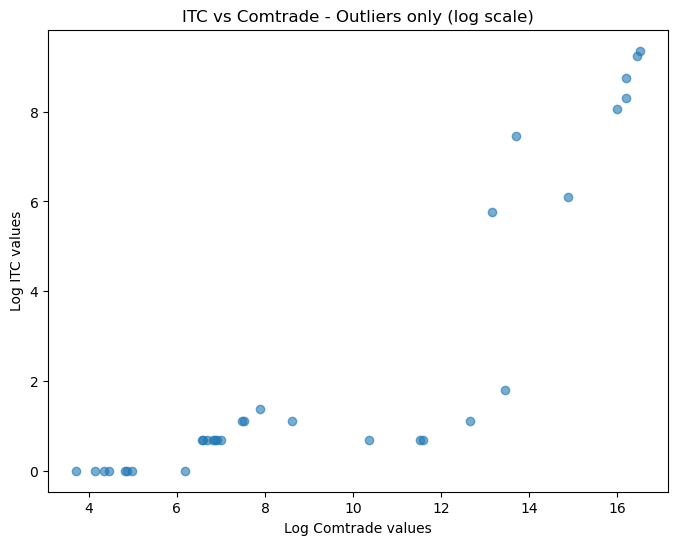

In [42]:
plt.figure(figsize=(8,6))
plt.scatter(corr_outliers["log_value_comtrade"], corr_outliers["log_value_itc"], alpha=0.6)

plt.xlabel("Log Comtrade values")
plt.ylabel("Log ITC values")
plt.title("ITC vs Comtrade - Outliers only (log scale)")
plt.show()